# 헤라 (자사분석)

## 리뷰 크롤링
- 원본 : 헤라_리뷰_최종_전체_23367개.csv
- 3/12 18:00 기준 크롤링
- 헤라 선케어 제품 7개, 아모레몰(자사몰)에서 수집하고자 함.
- URL = 'https://www.amoremall.com/kr/ko/product/detail?onlineProdSn={오프라인코드}&onlineProdCode={온라인코드}'
- 최종 컬럼
    * 제품명 | 제품 ID | 용량 | 판매가 | 정가 | 할인율 | 평점 | 총리뷰수 | 작성자 | 연령대 | 성별 | 피부타입 | 피부고민 | 별점 | 옵션 | 사용감 | 민감성 | 발림성 | 리뷰내용 | 작성일자
- 제품 ID열은 오프라인코드를 기준으로 작성하고자 함
- 가격관련 내용과 평점 및 총 리뷰 수는 제품이 7개인 관계로 직접 수집하고자 함

* 추가정보
  - 상품명 | 정가 | 판매가 | 할인율 | 평점 | 총리뷰수
  - UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g | 38000 34200 10% 4.8 1580
  - NEW UV프로텍터 CC SPF50+/PA++++ 50ml | 47000 42300 10% 4.8 32
  - NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml | 47000 42300 10% 4.6 38
  - UV프로텍터 익스트림포스 레포츠 SPF50+/PA++++ 70ml | 47000 42300 10% 4.9 849
  - UV프로텍터 프레쉬 SPF50+/PA++++ 50ml | 47000 42300 10% 4.8 2091
  - UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml | 47000 42300 10% 4.8 11340
  - UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml | 47000 42300 10% 4.8 7787

In [ ]:
import time
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, NoSuchElementException

# =========================
# 0. 제품 정보 추가
# =========================
products = [
    {
        "상품명": "UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g",
        "오프라인코드": "57792",
        "온라인코드": "111070001671"
    },
    {
        "상품명": "NEW UV프로텍터 CC SPF50+/PA++++ 50ml",
        "오프라인코드": "68574",
        "온라인코드": "111070002347"
    },
    {
        "상품명": "NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml",
        "오프라인코드": "68573",
        "온라인코드": "111070002346"
    },
    {
        "상품명": "UV프로텍터 익스트림포스 레포츠 SPF50+/PA++++ 70ml",
        "오프라인코드": "60900",
        "온라인코드": "111070001767"
    },
    {
        "상품명": "UV프로텍터 프레쉬 SPF50+/PA++++ 50ml",
        "오프라인코드": "56400",
        "온라인코드": "111070001630"
    },
    {
        "상품명": "UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml",
        "오프라인코드": "50165",
        "온라인코드": "111170101128"
    },
    {
        "상품명": "UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml",
        "오프라인코드": "18312",
        "온라인코드": "111070000458"
    }
]

# 1. 브라우저 설정
options = webdriver.ChromeOptions()
prefs = {"profile.managed_default_content_settings.images": 2} # 이미지 차단
options.add_experimental_option("prefs", prefs)
driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 10)

seen_reviews = set()
all_data = []

def extract_all_visible_reviews(html, product_name, offline_code, online_code, url):
    """현재 DOM에 로드된 모든 리뷰를 추출 (중복 제외)"""
    soup = BeautifulSoup(html, 'lxml')
    cards = [c for c in soup.select('div.reviewCard') if not c.find_parent(class_="modalPopupWrap")]

    new_items = []
    for card in cards:
        author = card.select_one('.profileCard__userTitle').get_text(strip=True) if card.select_one('.profileCard__userTitle') else ''
        date = card.select_one('.util .date').get_text(strip=True) if card.select_one('.util .date') else ''
        content = ""
        txt_elem = card.find('p', class_='txt', recursive=False) or card.select_one('p.txt')
        if txt_elem:
            content = txt_elem.get_text(strip=True)

        review_key = f"{product_name}_{author}_{date}_{content[:20]}"

        if review_key not in seen_reviews:
            seen_reviews.add(review_key)
            user_info = ", ".join([i.get_text(strip=True) for i in card.select('.profileCard__userDesc .item .txt')])
            star = ''
            star_elem = card.select_one('.icoStarWrap')
            if star_elem:
                for cls in star_elem.get('class', []):
                    if cls.startswith('star'):
                        star = cls[4:]
                        break
            option = card.select_one('.option').get_text(strip=True).replace('옵션:', '') if card.select_one('.option') else ''
            styles = " / ".join([f"{dt.text}: {dd.text.strip()}" for dt, dd in zip(card.select('.prdStyle dt'), card.select('.prdStyle dd'))])

            new_items.append({
                '상품명': product_name,
                '오프라인코드': offline_code,
                '온라인코드': online_code,
                'URL': url,
                '작성자': author,
                '사용자정보': user_info,
                '별점': star,
                '옵션': option,
                '상세평가': styles,
                '리뷰내용': content,
                '작성일자': date
            })
    return new_items

try:
    for product in products:
        product_name = product["상품명"]
        offline_code = product["오프라인코드"]
        online_code = product["온라인코드"]
        url = f"https://www.amoremall.com/kr/ko/product/detail?onlineProdSn={offline_code}&onlineProdCode={online_code}"

        print("=" * 60)
        print(f"상품 시작: {product_name}")

        driver.get(url)

        review_tab = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, 'button.tab[ap-click-name="상품상세_리뷰탭"]')))
        total_count = int(review_tab.find_element(By.CSS_SELECTOR, 'em.count').text.replace(',', ''))
        driver.execute_script("arguments[0].click();", review_tab)
        time.sleep(2)

        last_save_count = 0
        save_interval = 1000

        print(f":rocket: 수집 시작 (목표: {total_count}개)")

        # --- [반복문 시작] ---
        while True:
            current_dom_cards = driver.find_elements(By.CSS_SELECTOR, 'div.reviewCard')
            current_load_num = len(current_dom_cards)

            # 1,000개 단위 저장 시점
            if current_load_num - last_save_count >= save_interval:
                print(f"\n:package: {current_load_num}개 로드됨. 중간 저장 중...")
                new_batch = extract_all_visible_reviews(driver.page_source, product_name, offline_code, online_code, url)
                all_data.extend(new_batch)
                last_save_count = current_load_num
                pd.DataFrame(all_data).to_csv(f"헤라_리뷰_누적_{len(all_data)}개.csv", index=False, encoding='utf-8-sig')

            # 더 보기 클릭 시도
            try:
                more_btn = driver.find_element(By.XPATH, "//button[contains(@class, 'btnOutlined') and .//span[text()='더 보기']]")
                driver.execute_script("arguments[0].click();", more_btn)
                wait.until(lambda d: len(d.find_elements(By.CSS_SELECTOR, 'div.reviewCard')) > current_load_num)
                print(f"로딩 중... {current_load_num}/{total_count}", end='\r')
            except:
                print("\n:bell: 더 보기 버튼이 사라졌습니다. 로딩을 마칩니다.")
                break
        # --- [반복문 종료] ---

        # :white_check_mark: [핵심 추가] 반복문이 끝난 후, 마지막으로 남아있는 데이터를 추출하여 저장
        print(f"최종 추출 중... (현재 로드된 총 개수: {len(driver.find_elements(By.CSS_SELECTOR, 'div.reviewCard'))}개)")
        final_batch = extract_all_visible_reviews(driver.page_source, product_name, offline_code, online_code, url)
        all_data.extend(final_batch)

        # 상품 하나 끝날 때마다 중간 저장
        pd.DataFrame(all_data).to_csv("헤라_리뷰_전체_중간저장.csv", index=False, encoding='utf-8-sig')

    df = pd.DataFrame(all_data)
    final_filename = f"헤라_리뷰_최종_전체_{len(df)}개.csv"
    df.to_csv(final_filename, index=False, encoding='utf-8-sig')

    print("-" * 30)
    print(f":white_check_mark: 최종 수집 성공!")
    print(f"총 확보된 고유 리뷰: {len(df)}개")
    print(f"파일명: {final_filename}")
    print("-" * 30)

finally:
    driver.quit()

상품 시작: UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g
:rocket: 수집 시작 (목표: 1592개)
로딩 중... 990/1592
:package: 1000개 로드됨. 중간 저장 중...
로딩 중... 1570/1592
:bell: 더 보기 버튼이 사라졌습니다. 로딩을 마칩니다.
최종 추출 중... (현재 로드된 총 개수: 1580개)
상품 시작: NEW UV프로텍터 CC SPF50+/PA++++ 50ml
:rocket: 수집 시작 (목표: 33개)
로딩 중... 20/33
:bell: 더 보기 버튼이 사라졌습니다. 로딩을 마칩니다.
최종 추출 중... (현재 로드된 총 개수: 30개)
상품 시작: NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml
:rocket: 수집 시작 (목표: 40개)
로딩 중... 30/40
:bell: 더 보기 버튼이 사라졌습니다. 로딩을 마칩니다.
최종 추출 중... (현재 로드된 총 개수: 37개)
상품 시작: UV프로텍터 익스트림포스 레포츠 SPF50+/PA++++ 70ml
:rocket: 수집 시작 (목표: 854개)
로딩 중... 840/854
:bell: 더 보기 버튼이 사라졌습니다. 로딩을 마칩니다.
최종 추출 중... (현재 로드된 총 개수: 847개)
상품 시작: UV프로텍터 프레쉬 SPF50+/PA++++ 50ml
:rocket: 수집 시작 (목표: 2099개)
로딩 중... 990/2099
:package: 1000개 로드됨. 중간 저장 중...
로딩 중... 1990/2099
:package: 2000개 로드됨. 중간 저장 중...
로딩 중... 2080/2099
:bell: 더 보기 버튼이 사라졌습니다. 로딩을 마칩니다.
최종 추출 중... (현재 로드된 총 개수: 2090개)
상품 시작: UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml
:rocket: 수집 시작 (목표: 11349개)
로딩 중... 990/11349
:package: 1000개 로드됨. 중간 저장

In [ ]:
import pandas as pd
df = pd.read_csv('헤라_리뷰_최종_전체_23367개.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23367 entries, 0 to 23366
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   상품명     23367 non-null  object
 1   오프라인코드  23367 non-null  int64 
 2   온라인코드   23367 non-null  int64 
 3   URL     23367 non-null  object
 4   작성자     23367 non-null  object
 5   사용자정보   22855 non-null  object
 6   별점      23367 non-null  int64 
 7   옵션      23367 non-null  object
 8   상세평가    22132 non-null  object
 9   리뷰내용    23226 non-null  object
 10  작성일자    23367 non-null  object
dtypes: int64(3), object(8)
memory usage: 2.0+ MB


## 1차 정제
- 헤라_v3.csv로 저장됨

In [ ]:
df.head()

,상품명,오프라인코드,온라인코드,URL,작성자,사용자정보,별점,옵션,상세평가,리뷰내용,작성일자
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,111070001671,https://www.amoremall.com/kr/ko/product/detail...,gala*****,"20대, 여성, 복합성, 모공",5,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 보송해요 / 민감성: 순해요 / 발림성: 잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w\r\n햇살이 뜨거워지는 시기에 꼭 ...,2025.05.14
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,111070001671,https://www.amoremall.com/kr/ko/product/detail...,wltn***,"20대, 여성, 수분부족지성, 모공",3,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 유분기 있어요 / 민감성: 적당해요 / 발림성: 적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,111070001671,https://www.amoremall.com/kr/ko/product/detail...,tjdu*****,"20대, 여성, 건성, 건조함",5,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 적당해요 / 민감성: 순해요 / 발림성: 잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,111070001671,https://www.amoremall.com/kr/ko/product/detail...,마티니,"30대, 여성, 수분부족지성, 민감성",3,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 유분기 있어요 / 민감성: 적당해요 / 발림성: 잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,111070001671,https://www.amoremall.com/kr/ko/product/detail...,yjba****,"50대 이상, 여성, 건성, 주름",5,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 유분기 있어요 / 민감성: 적당해요 / 발림성: 잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11


### 결측 행 삭제 및 온라인코드, url 열 삭제

In [ ]:
df = df.dropna(subset=['사용자정보', '리뷰내용'])
df = df[(df['사용자정보'].str.strip() != '') & (df['리뷰내용'].str.strip() != '')]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22812 entries, 0 to 23365
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   상품명     22812 non-null  object
 1   오프라인코드  22812 non-null  int64 
 2   온라인코드   22812 non-null  int64 
 3   URL     22812 non-null  object
 4   작성자     22812 non-null  object
 5   사용자정보   22812 non-null  object
 6   별점      22812 non-null  int64 
 7   옵션      22812 non-null  object
 8   상세평가    22055 non-null  object
 9   리뷰내용    22812 non-null  object
 10  작성일자    22812 non-null  object
dtypes: int64(3), object(8)
memory usage: 2.1+ MB


In [ ]:
df = df.drop(columns=['온라인코드'])

In [ ]:
df = df.drop(columns=['URL'])

### 사용자 정보 및 상세 평가 값 분리

#### 사용자정보 열 관련 정제
- 사용자 정보에서 연령대 | 성별 | 피부타입 | 피부고민 나누었을 때 결측이 있는 행은 삭제한다.

In [ ]:
df[['연령대','성별','피부타입','피부고민']] = (
    df['사용자정보']
    .str.split(',', expand=True)
    .apply(lambda x: x.str.strip())
)
df.head()

,상품명,오프라인코드,URL,작성자,사용자정보,별점,옵션,상세평가,리뷰내용,작성일자,연령대,성별,피부타입,피부고민
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,gala*****,"20대, 여성, 복합성, 모공",5,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 보송해요 / 민감성: 순해요 / 발림성: 잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w\r\n햇살이 뜨거워지는 시기에 꼭 ...,2025.05.14,20대,여성,복합성,모공
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,wltn***,"20대, 여성, 수분부족지성, 모공",3,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 유분기 있어요 / 민감성: 적당해요 / 발림성: 적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,20대,여성,수분부족지성,모공
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,tjdu*****,"20대, 여성, 건성, 건조함",5,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 적당해요 / 민감성: 순해요 / 발림성: 잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,20대,여성,건성,건조함
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,마티니,"30대, 여성, 수분부족지성, 민감성",3,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 유분기 있어요 / 민감성: 적당해요 / 발림성: 잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,30대,여성,수분부족지성,민감성
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,yjba****,"50대 이상, 여성, 건성, 주름",5,UV프로텍터 액티브 선 밤 SPF50+PA4+,사용감: 유분기 있어요 / 민감성: 적당해요 / 발림성: 잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,50대 이상,여성,건성,주름


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22812 entries, 0 to 23365
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   상품명     22812 non-null  object
 1   오프라인코드  22812 non-null  int64 
 2   URL     22812 non-null  object
 3   작성자     22812 non-null  object
 4   사용자정보   22812 non-null  object
 5   별점      22812 non-null  int64 
 6   옵션      22812 non-null  object
 7   상세평가    22055 non-null  object
 8   리뷰내용    22812 non-null  object
 9   작성일자    22812 non-null  object
 10  연령대     22812 non-null  object
 11  성별      22786 non-null  object
 12  피부타입    21125 non-null  object
 13  피부고민    20174 non-null  object
dtypes: int64(2), object(12)
memory usage: 2.6+ MB


- 사용자정보 열 삭제 및 새로운 열 (네 개)의 결측 행 삭제

In [ ]:
df = df.dropna(subset=['연령대', '성별', '피부타입', '피부고민'])
df = df.drop(columns=['사용자정보'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20174 entries, 0 to 23357
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   상품명     20174 non-null  object
 1   오프라인코드  20174 non-null  int64 
 2   URL     20174 non-null  object
 3   작성자     20174 non-null  object
 4   별점      20174 non-null  int64 
 5   옵션      20174 non-null  object
 6   상세평가    19990 non-null  object
 7   리뷰내용    20174 non-null  object
 8   작성일자    20174 non-null  object
 9   연령대     20174 non-null  object
 10  성별      20174 non-null  object
 11  피부타입    20174 non-null  object
 12  피부고민    20174 non-null  object
dtypes: int64(2), object(11)
memory usage: 2.2+ MB


#### 상세평가 관련 열 정제


In [ ]:
temp = df['상세평가'].str.split('/', expand=True)

df['사용감'] = temp[0].str.split(':').str[1].str.strip()
df['민감성'] = temp[1].str.split(':').str[1].str.strip()
df['발림성'] = temp[2].str.split(':').str[1].str.strip()

df = df.drop(columns=['상세평가'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20174 entries, 0 to 23357
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   상품명     20174 non-null  object
 1   오프라인코드  20174 non-null  int64 
 2   URL     20174 non-null  object
 3   작성자     20174 non-null  object
 4   별점      20174 non-null  int64 
 5   옵션      20174 non-null  object
 6   리뷰내용    20174 non-null  object
 7   작성일자    20174 non-null  object
 8   연령대     20174 non-null  object
 9   성별      20174 non-null  object
 10  피부타입    20174 non-null  object
 11  피부고민    20174 non-null  object
 12  사용감     19990 non-null  object
 13  민감성     19990 non-null  object
 14  발림성     19990 non-null  object
dtypes: int64(2), object(13)
memory usage: 2.5+ MB


In [ ]:
df['발림성'].value_counts()

발림성
잘 발려요    12714
적당해요      7177
뻑뻑해요        70
무난해요        24
매트해요         4
글로시해요        1
Name: count, dtype: int64

In [ ]:
df = df.dropna(subset=['사용감', '민감성', '발림성'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19990 entries, 0 to 23357
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   상품명     19990 non-null  object
 1   오프라인코드  19990 non-null  int64 
 2   URL     19990 non-null  object
 3   작성자     19990 non-null  object
 4   별점      19990 non-null  int64 
 5   옵션      19990 non-null  object
 6   리뷰내용    19990 non-null  object
 7   작성일자    19990 non-null  object
 8   연령대     19990 non-null  object
 9   성별      19990 non-null  object
 10  피부타입    19990 non-null  object
 11  피부고민    19990 non-null  object
 12  사용감     19990 non-null  object
 13  민감성     19990 non-null  object
 14  발림성     19990 non-null  object
dtypes: int64(2), object(13)
memory usage: 2.4+ MB


In [ ]:
df.head()

,상품명,오프라인코드,URL,작성자,별점,옵션,리뷰내용,작성일자,연령대,성별,피부타입,피부고민,사용감,민감성,발림성
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,gala*****,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w\r\n햇살이 뜨거워지는 시기에 꼭 ...,2025.05.14,20대,여성,복합성,모공,보송해요,순해요,잘 발려요
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,wltn***,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,20대,여성,수분부족지성,모공,유분기 있어요,적당해요,적당해요
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,tjdu*****,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,20대,여성,건성,건조함,적당해요,순해요,잘 발려요
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,마티니,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,30대,여성,수분부족지성,민감성,유분기 있어요,적당해요,잘 발려요
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,https://www.amoremall.com/kr/ko/product/detail...,yjba****,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,50대 이상,여성,건성,주름,유분기 있어요,적당해요,잘 발려요


In [ ]:
df['연령대'].value_counts()

연령대
40대       7274
50대 이상    6593
30대       4769
20대       1316
10대         38
Name: count, dtype: int64

### 추가수집한 제품 정보 관련(가격정보 및 평점/리뷰 수) 열 생성

In [ ]:
product_info = pd.DataFrame({
    '상품명': [
        'UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g',
        'NEW UV프로텍터 CC SPF50+/PA++++ 50ml',
        'NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml',
        'UV프로텍터 익스트림포스 레포츠 SPF50+/PA++++ 70ml',
        'UV프로텍터 프레쉬 SPF50+/PA++++ 50ml',
        'UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml',
        'UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml'
    ],
    '정가': [38000, 47000, 47000, 47000, 47000, 47000, 47000],
    '판매가': [34200, 42300, 42300, 42300, 42300, 42300, 42300],
    '할인율': ['10%', '10%', '10%', '10%', '10%', '10%', '10%'],
    '평점': [4.8, 4.8, 4.6, 4.9, 4.8, 4.8, 4.8],
    '총리뷰수': [1580, 32, 38, 849, 2091, 11340, 7787]
})

In [ ]:
df = df.merge(product_info, on='상품명', how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19990 entries, 0 to 19989
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   상품명     19990 non-null  object 
 1   오프라인코드  19990 non-null  int64  
 2   작성자     19990 non-null  object 
 3   별점      19990 non-null  int64  
 4   옵션      19990 non-null  object 
 5   리뷰내용    19990 non-null  object 
 6   작성일자    19990 non-null  object 
 7   연령대     19990 non-null  object 
 8   성별      19990 non-null  object 
 9   피부타입    19990 non-null  object 
 10  피부고민    19990 non-null  object 
 11  사용감     19990 non-null  object 
 12  민감성     19990 non-null  object 
 13  발림성     19990 non-null  object 
 14  정가      19990 non-null  int64  
 15  판매가     19990 non-null  int64  
 16  할인율     19990 non-null  object 
 17  평점      19990 non-null  float64
 18  총리뷰수    19990 non-null  int64  
dtypes: float64(1), int64(5), object(13)
memory usage: 2.9+ MB


### 용량 열 생성

In [ ]:
df['용량'] = df['상품명'].str.extract(r'(\d+\s?(?:ml|g))$', expand=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19990 entries, 0 to 19989
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   상품명     19990 non-null  object 
 1   오프라인코드  19990 non-null  int64  
 2   작성자     19990 non-null  object 
 3   별점      19990 non-null  int64  
 4   옵션      19990 non-null  object 
 5   리뷰내용    19990 non-null  object 
 6   작성일자    19990 non-null  object 
 7   연령대     19990 non-null  object 
 8   성별      19990 non-null  object 
 9   피부타입    19990 non-null  object 
 10  피부고민    19990 non-null  object 
 11  사용감     19990 non-null  object 
 12  민감성     19990 non-null  object 
 13  발림성     19990 non-null  object 
 14  정가      19990 non-null  int64  
 15  판매가     19990 non-null  int64  
 16  할인율     19990 non-null  object 
 17  평점      19990 non-null  float64
 18  총리뷰수    19990 non-null  int64  
 19  용량      19990 non-null  object 
dtypes: float64(1), int64(5), object(14)
memory usage: 3.1+ MB


In [ ]:
df.head()

,상품명,오프라인코드,작성자,별점,옵션,리뷰내용,작성일자,연령대,성별,피부타입,피부고민,사용감,민감성,발림성,정가,판매가,할인율,평점,총리뷰수,용량
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,gala*****,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w\r\n햇살이 뜨거워지는 시기에 꼭 ...,2025.05.14,20대,여성,복합성,모공,보송해요,순해요,잘 발려요,38000,34200,10%,4.8,1580,10g
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,wltn***,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,20대,여성,수분부족지성,모공,유분기 있어요,적당해요,적당해요,38000,34200,10%,4.8,1580,10g
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,tjdu*****,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,20대,여성,건성,건조함,적당해요,순해요,잘 발려요,38000,34200,10%,4.8,1580,10g
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,마티니,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,30대,여성,수분부족지성,민감성,유분기 있어요,적당해요,잘 발려요,38000,34200,10%,4.8,1580,10g
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,yjba****,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,50대 이상,여성,건성,주름,유분기 있어요,적당해요,잘 발려요,38000,34200,10%,4.8,1580,10g


### 열이름 및 순서 정리

In [ ]:
df = df.rename(columns={
    '상품명':'제품명',
    '오프라인코드':'제품 ID'
})

In [ ]:
df = df[
[
'제품명',
'제품 ID',
'용량',
'판매가',
'정가',
'할인율',
'평점',
'총리뷰수',
'작성자',
'연령대',
'성별',
'피부타입',
'피부고민',
'별점',
'옵션',
'사용감',
'민감성',
'발림성',
'리뷰내용',
'작성일자'
]
]
df.columns

Index(['제품명', '제품 ID', '용량', '판매가', '정가', '할인율', '평점', '총리뷰수', '작성자', '연령대',
       '성별', '피부타입', '피부고민', '별점', '옵션', '사용감', '민감성', '발림성', '리뷰내용', '작성일자'],
      dtype='object')

In [ ]:
df.head()

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,성별,피부타입,피부고민,별점,옵션,사용감,민감성,발림성,리뷰내용,작성일자
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,gala*****,20대,여성,복합성,모공,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w\r\n햇살이 뜨거워지는 시기에 꼭 ...,2025.05.14
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,wltn***,20대,여성,수분부족지성,모공,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,tjdu*****,20대,여성,건성,건조함,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,마티니,30대,여성,수분부족지성,민감성,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,yjba****,50대 이상,여성,건성,주름,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11


### 리뷰내용 다듬기

In [ ]:
df['리뷰내용'] = df['리뷰내용'].str.replace(r'\s+', ' ', regex=True).str.strip()
df.head()

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,성별,피부타입,피부고민,별점,옵션,사용감,민감성,발림성,리뷰내용,작성일자
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,gala*****,20대,여성,복합성,모공,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,wltn***,20대,여성,수분부족지성,모공,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,tjdu*****,20대,여성,건성,건조함,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,마티니,30대,여성,수분부족지성,민감성,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,yjba****,50대 이상,여성,건성,주름,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11


In [ ]:
df.to_csv('헤라_v2.csv', index=False)

In [ ]:
import pandas as pd
df = pd.read_csv('헤라_v2.csv')
df

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,성별,피부타입,피부고민,별점,옵션,사용감,민감성,발림성,리뷰내용,작성일자
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,gala*****,20대,여성,복합성,모공,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,wltn***,20대,여성,수분부족지성,모공,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,tjdu*****,20대,여성,건성,건조함,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,마티니,30대,여성,수분부족지성,민감성,3,UV프로텍터 액티브 선 밤 SPF50+PA4+,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,yjba****,50대 이상,여성,건성,주름,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19985,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,7787,dkdl****,50대 이상,여성,건성,주름,5,헤라 선메이트프로텍터SPF50+PA+++50ML,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.12.01
19986,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,7787,dkdl****,50대 이상,여성,건성,주름,5,헤라 선메이트프로텍터SPF50+PA+++50ML,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.11.10
19987,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,7787,dkdl****,50대 이상,여성,건성,주름,5,헤라 선메이트프로텍터SPF50+PA+++50ML,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.09.28
19988,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,7787,very***,20대,여성,지성,건조함,5,헤라 선메이트프로텍터SPF50+PA+++50ML,적당해요,적당해요,잘 발려요,아모레퍼시픽몰에서 판매하는 UV 프로텍터를 저렴한 가격과 알찬구성으로 구입할 수 있...,2019.06.11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19990 entries, 0 to 19989
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제품명     19990 non-null  object 
 1   제품 ID   19990 non-null  int64  
 2   용량      19990 non-null  object 
 3   판매가     19990 non-null  int64  
 4   정가      19990 non-null  int64  
 5   할인율     19990 non-null  object 
 6   평점      19990 non-null  float64
 7   총리뷰수    19990 non-null  int64  
 8   작성자     19990 non-null  object 
 9   연령대     19990 non-null  object 
 10  성별      19990 non-null  object 
 11  피부타입    19990 non-null  object 
 12  피부고민    19990 non-null  object 
 13  별점      19990 non-null  int64  
 14  옵션      19990 non-null  object 
 15  사용감     19990 non-null  object 
 16  민감성     19990 non-null  object 
 17  발림성     19990 non-null  object 
 18  리뷰내용    19990 non-null  object 
 19  작성일자    19990 non-null  object 
dtypes: float64(1), int64(5), object(14)
memory usage: 3.1+ MB


### 중복처리

- 모든 열 중복행 1개 발견하여 제거함

In [ ]:
df[df.duplicated()]

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,성별,피부타입,피부고민,별점,옵션,사용감,민감성,발림성,리뷰내용,작성일자
4038,UV프로텍터 프레쉬 SPF50+/PA++++ 50ml,56400,50ml,42300,47000,10%,4.8,2091,wldp****,20대,여성,복합성,칙칙함,5,UV프로텍터 멀티디펜스 프레쉬 50ml,보송해요,순해요,잘 발려요,잘 받았습니다 감사합니다 재구매 의사 있습니다,2025.11.04


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19989 entries, 0 to 19989
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제품명     19989 non-null  object 
 1   제품 ID   19989 non-null  int64  
 2   용량      19989 non-null  object 
 3   판매가     19989 non-null  int64  
 4   정가      19989 non-null  int64  
 5   할인율     19989 non-null  object 
 6   평점      19989 non-null  float64
 7   총리뷰수    19989 non-null  int64  
 8   작성자     19989 non-null  object 
 9   연령대     19989 non-null  object 
 10  성별      19989 non-null  object 
 11  피부타입    19989 non-null  object 
 12  피부고민    19989 non-null  object 
 13  별점      19989 non-null  int64  
 14  옵션      19989 non-null  object 
 15  사용감     19989 non-null  object 
 16  민감성     19989 non-null  object 
 17  발림성     19989 non-null  object 
 18  리뷰내용    19989 non-null  object 
 19  작성일자    19989 non-null  object 
dtypes: float64(1), int64(5), object(14)
memory usage: 3.2+ MB


- 리뷰내용이 중복되는 것들이 있으나 아이디가 다르거나 제품이 다르거나 작성일자가 다른 경우들이 있어 일단은 남기기로 한다.

In [ ]:
df[df.duplicated(subset=['리뷰내용', '작성일자'], keep=False)].sort_values(['리뷰내용','작성일자'])

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,성별,피부타입,피부고민,별점,옵션,사용감,민감성,발림성,리뷰내용,작성일자
1394,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,zmfl****,30대,여성,복합성,민감성,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,보송해요,순해요,잘 발려요,가격대비 쓰기 좋아서 선물용으로도 좋습니다~ 샘플 넉넉히 들어있어요 맘에듭니다!!가...,2023.05.04
4153,UV프로텍터 프레쉬 SPF50+/PA++++ 50ml,56400,50ml,42300,47000,10%,4.8,2091,zmfl****,30대,여성,복합성,민감성,5,UV프로텍터 멀티디펜스 프레쉬 50ml,보송해요,순해요,잘 발려요,가격대비 쓰기 좋아서 선물용으로도 좋습니다~ 샘플 넉넉히 들어있어요 맘에듭니다!!가...,2023.05.04
1444,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,zmfl****,30대,여성,복합성,민감성,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,보송해요,순해요,잘 발려요,가격대비 쓰기 좋아서 선물용으로도 좋습니다~ 샘플 넉넉히 들어있어요 맘에듭니다!!가...,2023.05.28
4150,UV프로텍터 프레쉬 SPF50+/PA++++ 50ml,56400,50ml,42300,47000,10%,4.8,2091,zmfl****,30대,여성,복합성,민감성,5,UV프로텍터 멀티디펜스 프레쉬 50ml,보송해요,순해요,잘 발려요,가격대비 쓰기 좋아서 선물용으로도 좋습니다~ 샘플 넉넉히 들어있어요 맘에듭니다!!가...,2023.05.28
3552,UV프로텍터 프레쉬 SPF50+/PA++++ 50ml,56400,50ml,42300,47000,10%,4.8,2091,jyor******,40대,남성,복합성,민감성,5,UV프로텍터 멀티디펜스 프레쉬 50ml,적당해요,적당해요,적당해요,가벼워서좋아요 사은품가방너무조아요 가벼워서좋아요 사은품가방너무조아요,2023.06.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17930,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,7787,ren0***,40대,여성,복합성,민감성,5,UV프로텍터 멀티디펜스 50ml,보송해요,순해요,잘 발려요,헤라 썬크림은 항상 잘 쓰고 있었어요. 여름에 쓸 땐 눈 밑이 시큰거릴 때가 있어서...,2022.05.20
4471,UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,50165,50ml,42300,47000,10%,4.8,11340,0103*******,20대,여성,복합성,민감성,5,UV프로텍터 톤업 SPF50+PA4+ 50ml,보송해요,순해요,잘 발려요,헤라 유브이 프로텍트 톤업 선크림 구입했어요 용량은 50밀리 튜브 타입이라 위생적입...,2025.01.18
14442,UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,50165,50ml,42300,47000,10%,4.8,11340,xhvk*****,50대 이상,여성,복합성,민감성,5,UV프로텍터 톤업 SPF50+PA4+ 50ml,보송해요,순해요,잘 발려요,헤라 유브이 프로텍트 톤업 선크림 구입했어요 용량은 50밀리 튜브 타입이라 위생적입...,2025.01.18
198,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1580,min5***,40대,여성,건성,민감성,5,UV프로텍터 액티브 선 밤 SPF50+PA4+,보송해요,순해요,잘 발려요,헤라 톤업 선크림사용하다가 새로 나온거라서 주문해봤어요 건성피부인 저한테는 당겨요ㅠ...,2024.04.22


In [ ]:
df = df.reset_index(drop=True)
df.to_csv('헤라_v3.csv', index=False, encoding='utf-8-sig')

## 리뷰 별 주요 키워드 추출하여, 제품 특징 분석
- 챗봇api 사용하여 리뷰 별 주요 키워드 5개를 추출하여 리스트 형태로 하나의 열을 만들고자 함.
- 제품명 | 제품 ID | 용량 | 판매가 | 정가 | 할인율 | 평점 | 총리뷰수 | 작성자 | 연령대 | 성별 | 피부타입 | 피부고민 | 별점 | 사용감 | 민감성 | 발림성 | 리뷰내용 | 작성일자
- 기존 DF의 옵션 열은 제품명과 동일하여 삭제한다.

In [ ]:
# 옵션 열 삭제
import pandas as pd
df = pd.read_csv('헤라_v3.csv')
df = df.drop(columns=['옵션'])

- 정제 과정에서 총리뷰수에 변경된 사항이 있어서 총리뷰수 재정제해야 함

In [ ]:
df['총리뷰수'] = df.groupby('제품 ID')['제품 ID'].transform('count')

In [ ]:
df.to_csv('헤라_v4.csv', index=False)

### 제미나이 api 활용하여 키워드 추출

In [ ]:
import pandas as pd
df = pd.read_csv('헤라_v4.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19989 entries, 0 to 19988
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제품명     19989 non-null  object 
 1   제품 ID   19989 non-null  int64  
 2   용량      19989 non-null  object 
 3   판매가     19989 non-null  int64  
 4   정가      19989 non-null  int64  
 5   할인율     19989 non-null  object 
 6   평점      19989 non-null  float64
 7   총리뷰수    19989 non-null  int64  
 8   작성자     19989 non-null  object 
 9   연령대     19989 non-null  object 
 10  성별      19989 non-null  object 
 11  피부타입    19989 non-null  object 
 12  피부고민    19989 non-null  object 
 13  별점      19989 non-null  int64  
 14  사용감     19989 non-null  object 
 15  민감성     19989 non-null  object 
 16  발림성     19989 non-null  object 
 17  리뷰내용    19989 non-null  object 
 18  작성일자    19989 non-null  object 
dtypes: float64(1), int64(5), object(13)
memory usage: 2.9+ MB


In [ ]:
import pandas as pd
import google.generativeai as genai
def gemini(api_key, prompt, data):
    # 1. 모델 초기화 (API 키 설정 및 모델명 직접 지정)
    model_name = "gemini-2.5-flash-lite"  # 사용하려는 모델명 직접 입력
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel(model_name)
    # 2. 콘텐츠 생성 및 응답 반환
    # f-string을 사용하여 data와 prompt를 결합하여 하나의 입력으로 전달
    full_prompt = f"data: {data}\n{prompt}"
    response = model.generate_content(full_prompt)
    return response.text

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
MY_API_KEY = ' '
my_prompt ='''
# 키워드 추출

## 처리
- 리뷰내용 열을 확인
- 리뷰내용 열에서 후기의 흐름과 전반적인 내용에 맞는 '주요 키워드'를 추출
- 단순 표현 복사가 아니라 **의미 기준으로 정규화된 대표 키워드**로 통일하여 추출
- 같은 의미의 표현들은 서로 다른 말로 두지 말고 **하나의 대표 키워드로 묶어서 반환**

## 의미 통합 규칙
- 표현이 달라도 의미가 같으면 반드시 하나의 대표 키워드로 통합
- 대표 키워드는 가능한 한 **짧고 명확한 명사형/상태형**으로 작성
- 원문 표현을 그대로 길게 옮기지 말고 **공통 의미를 압축한 표준 키워드**로 변환
- 한 리뷰 안에서 유사 의미 키워드가 반복되면 하나만 남김
- 서로 겹치는 표현은 더 상위의 공통 의미로 정리

## 대표 키워드 통합 예시
- "재구매의향이 있는", "다시 사고싶은", "또 살 것 같은", "계속 쓰고 싶은" → '재구매원함'
- "눈이 아프지 않은", "눈시림 없는", "눈 자극 없는" → '눈자극없음'
- "피부트러블은 없어요", "트러블이 안 나는", "자극이 없는" → '저자극'
- "휴대하면서 바르기 좋은", "들고다니기 좋은", "휴대용으로 좋은" → '휴대성좋음'
- "화장 위에 덧발라도 밀리지 않는", "메이크업 위에 발라도 안 밀리는" → '메이크업밀림없음'
- "향이 거의 없는", "무향에 가까운", "향수와 안 섞이는" → '무향'
- "기초하고 이것만 발라도 되는", "프라이머 없이도 되는", "간편하게 화사한" → '간편메이크업용'
- "정착해야 할 아이", "계속 쓸 제품", "정착템" → '정착템'
- "대체재를 찾지 못한", "이걸 대체할 게 없는" → '대체불가'

## 키워드 범주의 예시
- "평소에 썬크림 바르면 눈이 아파 바르지는 못하는데 이건 너무 편하게 꼼꼼히 발라도 자극적이지 않습니다. 스틱형이라 외출시에 덧발라도 좋고 화장 위에 덧발라도 밀리지 않고 좋은 것 같습니다. 다른 제품보다 화장기 없이 이 스틱형 썬크림만 발라도 차단효과가서 화장을 잘 안 하게 되더라구요. 혹시 구석구석 안 발라졌다 싶으면 스틱으로 넓은 면에 바른 후 손으로 다시 펴발라도 됩니다. 자극적인 향도 아니고 향도 거의 없어서 향수와 향이 섞일 염려도 없어서 권할 만한 제품입니다."
→ ['저자극', '덧바르기좋음', '무향', '메이크업밀림없음', '스틱형']

- "쓰던제품이라그런가피부트러블은없어요 솔직히자외선차단이되는지는잘모르겠어요 그냥들고다니면서바르기좋아서샀거든요 바르는방법을상세히동영상으로올려주면좋을거같아요 바르고나면좀 매트한부분도있어요 눈시림이없어서쓰고있어요 가희제품처럼리필제품이나오면좋겠네요"
→ ['저자극', '차단효과체감적음', '휴대성좋음', '매트함', '눈자극없음']

- "휴대용으로 구입해 봅니다. 사무실이나 차 안에 사용합니다"
→ ['휴대용', '실내사용']

- "사용후기 좋다는게 많아서 그냥 별 기대없이 주문해봤는데 정착해야할 아이였네요. 평소 색조를 잘 안하는 편이라 썬크림바르고 프라이머바르고 쿠션찍고 했는데 이건 프라이머 쿠션이런거 필요 없는거같아요. 기초하고 요거하나면 얼굴이 화사해보이기까지 하네요 완전 정착템 확정입니다."
→ ['간편메이크업용', '화사함', '정착템']

- "헤라 선메이트 프로텍터는 워낙 베스트 템이라서 그냥 구매합니다. 잘 쓰도록 하겠습니다. 가성비 템만 나온다면 갈아타고 싶은데 아직까지 대체재를 찾지 못한 그런 아이템이에요. 만든 사람 정말 상 줘야 합니다. 고마워요."
→ ['베스트템', '대체불가', '만족도높음']

## 제한사항
- 키워드 개수 제한은 없으나 **한 행당 반드시 1개 이상의 키워드를 추출**
- 반드시 **의미 기준으로 정규화된 대표 키워드**만 반환
- 같은 뜻의 키워드를 여러 개로 나누지 말 것
- 문장형 표현 대신 **대표 개념어**로 반환
- **추가 정보는 절대 출력하지 말 것**

## 반환
- 키워드를 **리스트 형태로 반환**
- No additional information. Only answer returned list
- 리스트 안의 각 키워드는 반드시 **단따옴표로 감쌀 것**

예시
['키워드1', '키워드2', '키워드3']
'''


#### 테스트 코드

In [ ]:
gemini(MY_API_KEY, my_prompt, df['리뷰내용'][960])

"['휴대성좋음', '밀착력좋음', '잔여물없음', '발림성좋음']"

In [ ]:
df_sample = df.head(10)

In [ ]:
df_sample['keywords'] = df_sample['리뷰내용'].apply(lambda x: gemini(MY_API_KEY, my_prompt, x))
df_sample

/tmp/ipykernel_177/548981451.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['keywords'] = df_sample['리뷰내용'].apply(lambda x: gemini(MY_API_KEY, my_prompt, x))


,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,성별,피부타입,피부고민,별점,사용감,민감성,발림성,리뷰내용,작성일자,keywords
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,gala*****,20대,여성,복합성,모공,5,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14,"['선스틱', '덧바르기좋음', '휴대성좋음', '촉촉함', '메이크업위사용가능',..."
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,wltn***,20대,여성,수분부족지성,모공,3,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,"['덧바르기애매함', '재구매고려', '자극감있음', '유분감있음', '건조함', ..."
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,tjdu*****,20대,여성,건성,건조함,5,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,"['야외활동용', '자외선차단필수', '번거로움해소', '밤제형선호', '민감성피부..."
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,마티니,30대,여성,수분부족지성,민감성,3,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,"['기름짐', '빠른소진', '덧바름불편', '끈적임', '자외선차단용']"
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,yjba****,50대 이상,여성,건성,주름,5,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,"['끈적임적음', '덧바르기편함', '색묻어남없음', '휴대성좋음', '땀흘릴때사용..."
5,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,아모레노예,40대,여성,건성,칙칙함,5,보송해요,순해요,잘 발려요,이 상품은 튜브형 스프레이형 어떤 종류의 썬 제품이 있어도 꼭 구매하는 제품. 이니...,2025.03.05,"['튜브형', '스프레이형', '비교', '이니스프리', '헤라', '가볍고얇음',..."
6,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,오삼전일,30대,여성,건성,모공,5,보송해요,순해요,잘 발려요,헤라 선밤을 사용해보고 정말 만족했어요. 일반 선크림과 다르게 밤 타입이라 바를 때...,2025.06.22,"['촉촉함', '부드러움', '밀착력', '백탁없음', '자연스러운톤업', '얇은발..."
7,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,73jj***,50대 이상,여성,건성,건조함,5,유분기 있어요,적당해요,적당해요,사용 간편성 때문에 (특히 여행시) 헤라 선스틱을 사용하고 있는데 많이 건조해지는 ...,2026.02.20,"['건조한피부용', '유분막형성', '각질개선', '환절기추천', '겨울철추천']"
8,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,khr3*****,50대 이상,여성,건성,건조함,5,보송해요,순해요,잘 발려요,"평상시 헤라 익스트림 포스 레포츠를 팔,다리쪽에 바르는데 부산2박3일 여행에 쓰려고...",2024.08.08,"['덧바르기좋음', '밀림없음', '스틱형', '양아쉬움', '3중기능성']"
9,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,0109*******,30대,여성,중성,칙칙함,5,유분기 있어요,순해요,잘 발려요,처음 출시됐을 때 1+1으로 구입해 사용해 본 후 쭉 쓰고 있어요 가방에 하나 집에...,2024.07.17,"['1+1할인', '재구매', '휴대성좋음', '덧바르기좋음', '촉촉함', '손에..."


#### 실전코드

In [ ]:
df['키워드'] = df['리뷰내용'].apply(lambda x: gemini(MY_API_KEY, my_prompt, x))
df

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1013.74ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1063.50ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 785.92ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 761.21ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1041.28ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1674.28ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 811.23ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:gener

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,성별,피부타입,피부고민,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,gala*****,20대,여성,복합성,모공,5,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14,"['선스틱', '덧바르기좋음', '휴대성좋음', '투명발림', '메이크업밀림없음',..."
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,wltn***,20대,여성,수분부족지성,모공,3,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,"['사무실덧바름쏘쏘', '피부자극있음', '유분감있음', '자연스러운광', '아웃도..."
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,tjdu*****,20대,여성,건성,건조함,5,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,"['야외활동용', '자외선차단필수', '덧바르기좋음', '민감성피부용', '휴대성좋..."
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,마티니,30대,여성,수분부족지성,민감성,3,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,"['기름짐', '사용량많음', '미끌거림', '끈적임']"
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,yjba****,50대 이상,여성,건성,주름,5,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,"['끈적임적음', '덧바르기편함', '색묻어남없음', '휴대성좋음', '양적음']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19984,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,여성,건성,주름,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.12.01,['만족']
19985,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,여성,건성,주름,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.11.10,['만족도높음']
19986,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,여성,건성,주름,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.09.28,"['만족도높음', '호감', '추천']"
19987,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,very***,20대,여성,지성,건조함,5,적당해요,적당해요,잘 발려요,아모레퍼시픽몰에서 판매하는 UV 프로텍터를 저렴한 가격과 알찬구성으로 구입할 수 있...,2019.06.11,"['저렴한가격', '알찬구성', '향이좋음', '자극적이지않음', '대량구매가능']"


### 키워드열 정제

In [ ]:
df['키워드'].sort_values()

,키워드
18475,"- ""아직 사용전이라 잘 모르겠네요 추후 다시 작성해요""\n→ ['사용전']"
3896,"- ""평소에 썬크림 바르면 눈이 아파 바르지는 못하는데 이건 너무 편하게 꼼꼼히 발..."
14795,"[' sale참여', ' 기대감', ' 피부안정기원']"
9,"['1+1구매', '재구매', '덧바르기좋음', '촉촉함', '끈적임없음', '이지..."
15169,"['1+1행사', '선크림', '선물용', '샘플용량아쉬움']"
...,...
19744,[]
401,[]
18268,[]
9495,"```json\n[\n""저자극"",\n""덧바르기좋음"",\n""무향"",\n""메이크업밀림없..."


In [ ]:
import ast
import numpy as np

def is_valid_non_empty_list_string(s):
    if not isinstance(s, str):
        return False
    try:
        evaluated_list = ast.literal_eval(s)
        return isinstance(evaluated_list, list) and len(evaluated_list) > 0
    except (ValueError, SyntaxError):
        return False

# Identify rows where '키워드' is not a valid, non-empty list string
invalid_keywords_mask = ~df['키워드'].apply(is_valid_non_empty_list_string)

# Display these rows
print("Rows with invalid or empty list-like entries in '키워드' column:")
display(df[invalid_keywords_mask])


Rows with invalid or empty list-like entries in '키워드' column:


,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,성별,피부타입,피부고민,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드
401,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,kwon****,40대,여성,복합성,트러블,3,적당해요,적당해요,적당해요,ㅓsnhhsggsjsjsbbdndkowjdhbxbdbnxjlwlsjdjjhhxbdb...,2024.10.22,[]
2890,UV프로텍터 프레쉬 SPF50+/PA++++ 50ml,56400,50ml,42300,47000,10%,4.8,1881,ap48****,40대,남성,건성,주름,5,보송해요,순해요,잘 발려요,jtwejtekykurmeyengnwtjwtwjtejyrmhngdsngsbtwbtw...,2025.04.22,"['반복사용', '반복사용', '반복사용', '반복사용', '반복사용', '반복사용..."
3896,UV프로텍터 프레쉬 SPF50+/PA++++ 50ml,56400,50ml,42300,47000,10%,4.8,1881,jhk2***,40대,여성,복합성,칙칙함,5,보송해요,순해요,잘 발려요,... ..... ..... ... ... .... ...,2023.03.25,"- ""평소에 썬크림 바르면 눈이 아파 바르지는 못하는데 이건 너무 편하게 꼼꼼히 발..."
6141,UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,50165,50ml,42300,47000,10%,4.8,10442,lotu****,50대 이상,남성,건성,트러블,5,보송해요,순해요,잘 발려요,겨울철이지만 피부관리를 위해서는 자외선 차단이 꼭 필요한데 톤업 까지 되는 제품이 ...,2025.02.04,"['톤업가능', '발림성좋음', '순함', '촉촉함유"
6226,UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,50165,50ml,42300,47000,10%,4.8,10442,hmr0***,30대,여성,복합성,탄력없음,4,적당해요,적당해요,적당해요,제가 쓰려고 산거는 아니고 선물용으로 구매ㅐ했어요. 원래 쓰시던 제품이라고 해서 헤...,2025.09.15,"['선물용', '선물용', '선물용', '선물용', '선물용', '선물용', '선물..."
7549,UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,50165,50ml,42300,47000,10%,4.8,10442,love****,40대,여성,수분부족지성,모공,5,적당해요,적당해요,적당해요,.................................................,2025.02.17,data: 20220813 084601 / .........................
9495,UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,50165,50ml,42300,47000,10%,4.8,10442,afte*****,40대,남성,건성,트러블,5,적당해요,적당해요,적당해요,............................................,2026.02.11,"```json\n[\n""저자극"",\n""덧바르기좋음"",\n""무향"",\n""메이크업밀림없..."
10925,UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,50165,50ml,42300,47000,10%,4.8,10442,bigw********,50대 이상,여성,건성,주름,5,보송해요,순해요,잘 발려요,발림성이 좋고 촉촉함이 오래감. 용기 뚜껑이 잘 닫히고 고급스러움,2024.05.30,"['발림성좋음', '촉촉함유"
17407,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,0105*******,40대,남성,복합성,민감성,5,적당해요,적당해요,적당해요,겨울철에 선크림은 필수 아이템이죠 품절되어서 풀리길 계속기다렸다가 구매했어요 백탁 ...,2022.12.25,"['겨울철필수템', '재구매의사있음', '백탁없음', '건조함없음', '칙칙함없음'..."
18268,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,mai0***,30대,남성,중성,모공,5,보송해요,순해요,잘 발려요,Kavdjd ekzkow d mữi skiwijsbdbeubwjsom eishdbb...,2022.08.20,[]


In [ ]:
df = df[~invalid_keywords_mask]
df['키워드'].sort_values()

,키워드
14795,"[' sale참여', ' 기대감', ' 피부안정기원']"
9,"['1+1구매', '재구매', '덧바르기좋음', '촉촉함', '끈적임없음', '이지..."
15169,"['1+1행사', '선크림', '선물용', '샘플용량아쉬움']"
18185,"['1+1행사', '첫사용']"
10065,"['10개이상사용', '핑크색상선호', '화장전사용적합']"
...,...
6924,"['흡착력좋음', '보습력좋음', '화사함', '윤기있음', '당김없음', '밀림없..."
15257,"['흡착력좋음', '즉각흡수', '번들거림없음', '밀착력좋음', '최고의선크림']"
17183,"['흰색 선크림', '톤업 선크림', '보습력', '피부 커버', '발림성', '톤..."
15702,"['흰색', '발림성우수', '자외선차단우수']"


In [ ]:
df['키워드'].value_counts()

,count
키워드,
"['만족도높음', '재구매원함']",66
['만족'],64
['만족도높음'],46
['재구매원함'],42
"['재구매원함', '만족도높음']",29
...,...
"['애정템', '추천템', '생기있음', '윤기있음', '촉촉함', '자연스러움']",1
"['발림성좋음', '제형좋음', '유분감많음', '톤업효과무너짐', '팩트사용시개선', '톤업크림아님', '티안나는톤업']",1
"['톤업', '촉촉함', '화사함', '재구매']",1


In [ ]:
df.to_csv('헤라_v5.csv', index=False, encoding='utf-8-sig')

## 리뷰 감성 분석

In [ ]:
import pandas as pd
df = pd.read_csv('헤라_v5.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19975 entries, 0 to 19974
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제품명     19975 non-null  object 
 1   제품 ID   19975 non-null  int64  
 2   용량      19975 non-null  object 
 3   판매가     19975 non-null  int64  
 4   정가      19975 non-null  int64  
 5   할인율     19975 non-null  object 
 6   평점      19975 non-null  float64
 7   총리뷰수    19975 non-null  int64  
 8   작성자     19975 non-null  object 
 9   연령대     19975 non-null  object 
 10  성별      19975 non-null  object 
 11  피부타입    19975 non-null  object 
 12  피부고민    19975 non-null  object 
 13  별점      19975 non-null  int64  
 14  사용감     19975 non-null  object 
 15  민감성     19975 non-null  object 
 16  발림성     19975 non-null  object 
 17  리뷰내용    19975 non-null  object 
 18  작성일자    19975 non-null  object 
 19  키워드     19975 non-null  object 
dtypes: float64(1), int64(5), object(14)
memory usage: 3.0+ MB


In [ ]:
! pip install google-generativeai

In [ ]:
import pandas as pd
import google.generativeai as genai
def gemini(api_key, prompt, data):
    # 1. 모델 초기화 (API 키 설정 및 모델명 직접 지정)
    model_name = "gemini-2.5-flash-lite"  # 사용하려는 모델명 직접 입력
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel(model_name)
    # 2. 콘텐츠 생성 및 응답 반환
    # f-string을 사용하여 data와 prompt를 결합하여 하나의 입력으로 전달
    full_prompt = f"data: {data}\n{prompt}"
    response = model.generate_content(full_prompt)
    return response.text

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
MY_API_KEY = ' '
my_prompt ='''
# 감성 분석

## 처리
- 리뷰내용을 읽고 문맥을 기반으로 전반적인 감성을 판단
- 단순 단어가 아니라 **리뷰의 전체 의미와 흐름**을 기준으로 판단
- 리뷰의 전반적인 만족도가 중심이 되는 감정을 선택

## 감성 분류 기준
- **긍정**
  - 제품에 대한 만족, 추천, 재구매 의사 등이 나타나는 경우
  - 장점이 중심이고 단점 언급이 거의 없는 경우

- **부정**
  - 제품에 대한 불만, 실망, 비추천 의도가 나타나는 경우
  - 단점이 중심이거나 기대에 미치지 못한 경우

- **중립**
  - 장점과 단점이 함께 존재하는 경우
  - 평가가 명확하지 않거나 단순 사용 후기인 경우
  - 긍정과 부정 요소가 동시에 나타나는 경우

## 판단 규칙
- 장점과 단점이 모두 언급되면 **중립**으로 판단
- 단점이 매우 강하게 나타나면 **부정**
- 만족, 추천, 재구매 의사가 명확하면 **긍정**
- 감정이 드러나지 않는 정보성 후기 역시 **중립**

## 제한사항
- 반드시 하나의 감성만 선택
- 추가 설명 금지
- 결과는 감성 단어만 반환

## 반환 형식
- '긍정' 또는 '부정' 또는 '중립'
- No additional information. Only answer returned list
'''


### 테스트코드

In [ ]:
gemini(MY_API_KEY, my_prompt, df['리뷰내용'][960])

'중립'

In [ ]:
df['리뷰내용'][960]

'향이 은은해서 좋습니다. 휴대하기도 사용하기도 간편해서 제주도 여행시 아주아주 잘 사용했습니다. 쓱쓱 발라주면 되고 발림성도 좋아요. 단점이라면 좀 물러서인지 잘 찍히네요...닳는 것이 팍팍 보이기도 하고요. 가격대비 양이 적다고 느껴집니다.'

In [ ]:
df_sample = df.head(10)

In [ ]:
df_sample['감성분석'] = df_sample['리뷰내용'].apply(lambda x: gemini(MY_API_KEY, my_prompt, x))
df_sample

/tmp/ipykernel_2595/2263491297.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['감성분석'] = df_sample['리뷰내용'].apply(lambda x: gemini(MY_API_KEY, my_prompt, x))


,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,...,피부타입,피부고민,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드,감성분석
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,gala*****,20대,...,복합성,모공,5,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14,"['선스틱', '덧바르기좋음', '휴대성좋음', '투명발림', '메이크업밀림없음',...",긍정
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,wltn***,20대,...,수분부족지성,모공,3,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,"['사무실덧바름쏘쏘', '피부자극있음', '유분감있음', '자연스러운광', '아웃도...",중립
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,tjdu*****,20대,...,건성,건조함,5,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,"['야외활동용', '자외선차단필수', '덧바르기좋음', '민감성피부용', '휴대성좋...",긍정
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,마티니,30대,...,수분부족지성,민감성,3,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,"['기름짐', '사용량많음', '미끌거림', '끈적임']",부정
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,yjba****,50대 이상,...,건성,주름,5,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,"['끈적임적음', '덧바르기편함', '색묻어남없음', '휴대성좋음', '양적음']",중립
5,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,아모레노예,40대,...,건성,칙칙함,5,보송해요,순해요,잘 발려요,이 상품은 튜브형 스프레이형 어떤 종류의 썬 제품이 있어도 꼭 구매하는 제품. 이니...,2025.03.05,"['스틱형', '이니스프리비교', '헤라추천', '얇고가벼움', '덧바르기좋음', ...",중립
6,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,오삼전일,30대,...,건성,모공,5,보송해요,순해요,잘 발려요,헤라 선밤을 사용해보고 정말 만족했어요. 일반 선크림과 다르게 밤 타입이라 바를 때...,2025.06.22,"['촉촉함', '부드러움', '밀착력', '백탁없음', '톤업', '자연스러움', ...",긍정
7,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,73jj***,50대 이상,...,건성,건조함,5,유분기 있어요,적당해요,적당해요,사용 간편성 때문에 (특히 여행시) 헤라 선스틱을 사용하고 있는데 많이 건조해지는 ...,2026.02.20,"['건조함개선', '각질방지', '유분막형성', '추천']",긍정
8,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,khr3*****,50대 이상,...,건성,건조함,5,보송해요,순해요,잘 발려요,"평상시 헤라 익스트림 포스 레포츠를 팔,다리쪽에 바르는데 부산2박3일 여행에 쓰려고...",2024.08.08,"['여행용', '덧바르기좋음', '메이크업밀림없음', '스틱형', '용량아쉬움', ...",중립
9,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,0109*******,30대,...,중성,칙칙함,5,유분기 있어요,순해요,잘 발려요,처음 출시됐을 때 1+1으로 구입해 사용해 본 후 쭉 쓰고 있어요 가방에 하나 집에...,2024.07.17,"['1+1구매', '재구매', '덧바르기좋음', '촉촉함', '끈적임없음', '이지...",긍정


### 실전코드

In [ ]:
df['감성분석'] = df['리뷰내용'].apply(lambda x: gemini(MY_API_KEY, my_prompt, x))
df

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1012.99ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 784.51ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 810.22ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 860.01ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1241.75ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 860.39ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1720.30ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:genera

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,...,피부타입,피부고민,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드,감성분석
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,gala*****,20대,...,복합성,모공,5,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14,"['선스틱', '덧바르기좋음', '휴대성좋음', '투명발림', '메이크업밀림없음',...",긍정
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,wltn***,20대,...,수분부족지성,모공,3,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,"['사무실덧바름쏘쏘', '피부자극있음', '유분감있음', '자연스러운광', '아웃도...",중립
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,tjdu*****,20대,...,건성,건조함,5,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,"['야외활동용', '자외선차단필수', '덧바르기좋음', '민감성피부용', '휴대성좋...",긍정
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,마티니,30대,...,수분부족지성,민감성,3,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,"['기름짐', '사용량많음', '미끌거림', '끈적임']",부정
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,yjba****,50대 이상,...,건성,주름,5,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,"['끈적임적음', '덧바르기편함', '색묻어남없음', '휴대성좋음', '양적음']",중립
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19970,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,...,건성,주름,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.12.01,['만족'],긍정
19971,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,...,건성,주름,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.11.10,['만족도높음'],긍정
19972,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,...,건성,주름,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.09.28,"['만족도높음', '호감', '추천']",긍정
19973,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,very***,20대,...,지성,건조함,5,적당해요,적당해요,잘 발려요,아모레퍼시픽몰에서 판매하는 UV 프로텍터를 저렴한 가격과 알찬구성으로 구입할 수 있...,2019.06.11,"['저렴한가격', '알찬구성', '향이좋음', '자극적이지않음', '대량구매가능']",긍정


In [ ]:
df.to_csv('헤라_v6.csv', index = False)

## 정제 및 긍정률 열 추가
- 긍부정/중립 리뷰 별 키워드 분석할 수 있다.
- 긍정의 리뷰에는 1, 중립의 리뷰에는 0.5, 부정의 리뷰는 0의 가중치를 두고 제품별 긍정률을 계산하여 확인한다.
- 세부적으로는 고객 세그먼트별 긍정률(만족도) 및 키워드를 비교할 수 있다.

In [ ]:
import pandas as pd
import ast

df = pd.read_csv('헤라_v6.csv')
df['키워드'] = df['키워드'].apply(ast.literal_eval)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19975 entries, 0 to 19974
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제품명     19975 non-null  object 
 1   제품 ID   19975 non-null  int64  
 2   용량      19975 non-null  object 
 3   판매가     19975 non-null  int64  
 4   정가      19975 non-null  int64  
 5   할인율     19975 non-null  object 
 6   평점      19975 non-null  float64
 7   총리뷰수    19975 non-null  int64  
 8   작성자     19975 non-null  object 
 9   연령대     19975 non-null  object 
 10  성별      19975 non-null  object 
 11  피부타입    19975 non-null  object 
 12  피부고민    19975 non-null  object 
 13  별점      19975 non-null  int64  
 14  사용감     19975 non-null  object 
 15  민감성     19975 non-null  object 
 16  발림성     19975 non-null  object 
 17  리뷰내용    19975 non-null  object 
 18  작성일자    19975 non-null  object 
 19  키워드     19975 non-null  object 
 20  감성분석    19975 non-null  object 
dtypes: float64(1), int64(5), object(15)

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,...,피부타입,피부고민,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드,감성분석
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,gala*****,20대,...,복합성,모공,5,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14,"[선스틱, 덧바르기좋음, 휴대성좋음, 투명발림, 메이크업밀림없음, 주름개선, 미백효과]",긍정
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,wltn***,20대,...,수분부족지성,모공,3,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,"[사무실덧바름쏘쏘, 피부자극있음, 유분감있음, 자연스러운광, 아웃도어추천, 여름철덧...",중립
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,tjdu*****,20대,...,건성,건조함,5,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,"[야외활동용, 자외선차단필수, 덧바르기좋음, 민감성피부용, 휴대성좋음, 투명하게발림...",긍정
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,마티니,30대,...,수분부족지성,민감성,3,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,"[기름짐, 사용량많음, 미끌거림, 끈적임]",부정
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,yjba****,50대 이상,...,건성,주름,5,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,"[끈적임적음, 덧바르기편함, 색묻어남없음, 휴대성좋음, 양적음]",중립


In [ ]:
df['감성분석'].value_counts()

,count
감성분석,
긍정,17119
중립,2695
부정,160
"This is a good starting point for a sentiment analysis task. You've clearly outlined the goals, criteria, rules, and limitations.\n\nHowever, the `data: .... ..... ...... ...... ..... ........ ...... .... ..... .......` part is not actual data. It's a placeholder. To provide a useful response, I need to see the actual text you want to analyze.\n\n**Please provide the review text you want me to perform sentiment analysis on.**\n\nOnce you provide the text, I will apply your rules and return only '긍정', '부정', or '중립'.",1


In [ ]:
df = df[df['감성분석'].isin(['긍정', '중립', '부정'])]
df['감성분석'].value_counts()

sentiment_scores = {
    '긍정': 1,
    '중립': 0.5,
    '부정': 0
}

df['감성점수'] = df['감성분석'].map(sentiment_scores)

# 제품별 긍정률 계산 (평균 감성점수)
df['긍정률'] = df.groupby('제품 ID')['감성점수'].transform('mean')

# '감성점수' 열은 더 이상 필요 없으므로 삭제합니다.
df = df.drop(columns=['감성점수'])

df.head()

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,...,피부고민,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드,감성분석,긍정률
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,gala*****,20대,...,모공,5,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14,"[선스틱, 덧바르기좋음, 휴대성좋음, 투명발림, 메이크업밀림없음, 주름개선, 미백효과]",긍정,0.83391
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,wltn***,20대,...,모공,3,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,"[사무실덧바름쏘쏘, 피부자극있음, 유분감있음, 자연스러운광, 아웃도어추천, 여름철덧...",중립,0.83391
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,tjdu*****,20대,...,건조함,5,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,"[야외활동용, 자외선차단필수, 덧바르기좋음, 민감성피부용, 휴대성좋음, 투명하게발림...",긍정,0.83391
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,마티니,30대,...,민감성,3,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,"[기름짐, 사용량많음, 미끌거림, 끈적임]",부정,0.83391
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,yjba****,50대 이상,...,주름,5,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,"[끈적임적음, 덧바르기편함, 색묻어남없음, 휴대성좋음, 양적음]",중립,0.83391


## (1차분석) 감성별 키워드 분석 (top10)
- 1. 헤라 선케어 전제품 기준, 긍정/부정/중립 별 가장 많이 도출된 키워드 분석
- 2. 톤업 선크림(신제품) 긍정/부정/중립 별 가장 많이 도출된 키워드 분석
- 3. 톤업 선크림(신제품) 연령대와 성별, 긍정/부정/중립 별 가장 많이 도출된 키워드 분석

- 중복되는 의미의 키워드나, 인사이트를 추출할 수 없는 키워드를 고려하여 일단 20개씩 추출한 후 키워드 정제하여 10개를 다시 추출 -> 시각화(막대그래프)

### 1. 헤라 선케어 전제품 기준 긍정/부정/중립 별 키워드 top10
- 중립의 top10 키워드는 대부분 긍정 단어로 이루어져 있음을 확인하여 앞으로의 분석에서도 긍정/부정만 중점적으로 확인하기로 한다.
- 1차 키워드 정제 후 - 시각화

### 분석 결과
-  헤라 사용자들은 톤업기능을 중요하게 여긴다. 긍/부정 모두 톤업 기능에 대한 키워드가 존재함
  * 부정 리뷰에선 번들기린다(유분감)는 의견이 있음
  * 긍정 리뷰에선 촉촉하고 발림성이 좋다는 의견
  => 피부 타입에 따라 느끼는 제품 특징이 달라지는 것으로 보인다.

#### 중립

In [ ]:
reviews = df[df['감성분석'] == '중립']
exploded_keywords = reviews.explode('키워드')
keyword_counts = exploded_keywords['키워드'].value_counts()
display(keyword_counts.head(20))

,count
키워드,
톤업,426
발림성좋음,407
촉촉함,247
휴대성좋음,192
재구매의향,150
유분감있음,134
순함,123
백탁없음,117
유분감,109


#### 긍정

In [ ]:
positive_reviews = df[df['감성분석'] == '긍정']
exploded_positive_keywords = positive_reviews.explode('키워드')
positive_keyword_counts = exploded_positive_keywords['키워드'].value_counts()
display(positive_keyword_counts.head(20))

,count
키워드,
재구매의향,3626
발림성좋음,3360
톤업,3316
촉촉함,2522
만족도높음,2044
순함,1368
끈적임없음,1212
화사함,1176
백탁없음,1119


In [ ]:
keyword_map = {
    '톤업효과': '톤업',

    '재구매의사있음': '재구매의향',
    '재구매의향있음': '재구매의향',
    '재구매의향': '재구매의향',
    '재구매원함': '재구매의향',
    '보습감': '촉촉함',

    '순함': '순함',
    '저자극': '순함',

    '발림성좋음': '발림성좋음',
    '잘발림': '발림성좋음',
}

In [ ]:
df['키워드'] = df['키워드'].apply(
    lambda keywords: [
        keyword_map.get(k.strip(), k.strip()) for k in keywords
    ] if isinstance(keywords, list) else keywords
)

In [ ]:
positive_reviews = df[df['감성분석'] == '긍정']
exploded_positive_keywords = positive_reviews.explode('키워드')
positive_keyword_counts = exploded_positive_keywords['키워드'].value_counts()
display(positive_keyword_counts.head(10))

,count
키워드,
재구매의향,3626
발림성좋음,3360
톤업,3316
촉촉함,2522
만족도높음,2044
순함,1368
끈적임없음,1212
화사함,1176
백탁없음,1119


#### 부정

In [ ]:
negative_reviews = df[df['감성분석'] == '부정']
exploded_negative_keywords = negative_reviews.explode('키워드')
negative_keyword_counts = exploded_negative_keywords['키워드'].value_counts()
display(negative_keyword_counts.head(20))

,count
키워드,
재구매의사없음,11
번들거림,9
눈시림,9
기대이하,9
유분감많음,7
재구매의향없음,6
톤업효과미미,6
발림성별로,5
뭉침,5


In [ ]:
category_map = {
'재구매의사없음' : '재구매의향없음',
'톤업효과미미' : '톤업효과미흡'
}

In [ ]:
df['키워드'] = df['키워드'].apply(
    lambda keywords: [
       category_map.get(k.strip(), k.strip()) for k in keywords
    ] if isinstance(keywords, list) else keywords
)

In [ ]:
negative_reviews = df[df['감성분석'] == '부정']
exploded_negative_keywords = negative_reviews.explode('키워드')
negative_keyword_counts = exploded_negative_keywords['키워드'].value_counts()
display(negative_keyword_counts.head(10))

,count
키워드,
재구매의향없음,17
톤업효과미흡,11
눈시림,9
번들거림,9
기대이하,9
유분감많음,7
발림성별로,5
뭉침,5
가격인상,5


#### 그래프로 시각화

In [ ]:
# 한글 폰트
import pandas as pd
import numpy as np
# Install Korean font
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
# Configure Matplotlib to use NanumGothic
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking minus sign

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 142 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype

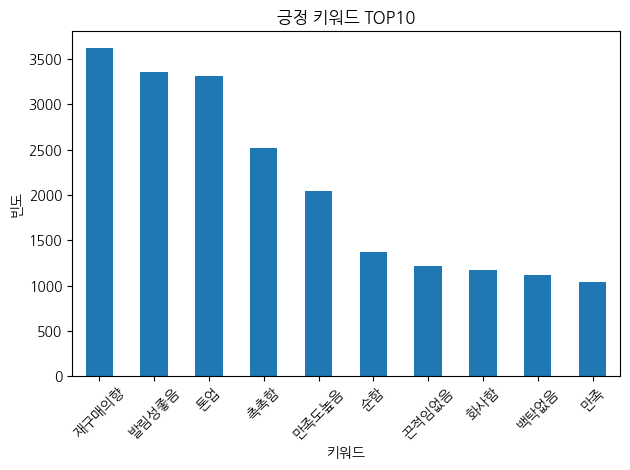

In [ ]:
import matplotlib.pyplot as plt

# 긍정 키워드 상위 10개
top10 = positive_keyword_counts.head(10)

plt.figure()
top10.plot(kind='bar')

plt.title('긍정 키워드 TOP10')
plt.xlabel('키워드')
plt.ylabel('빈도')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

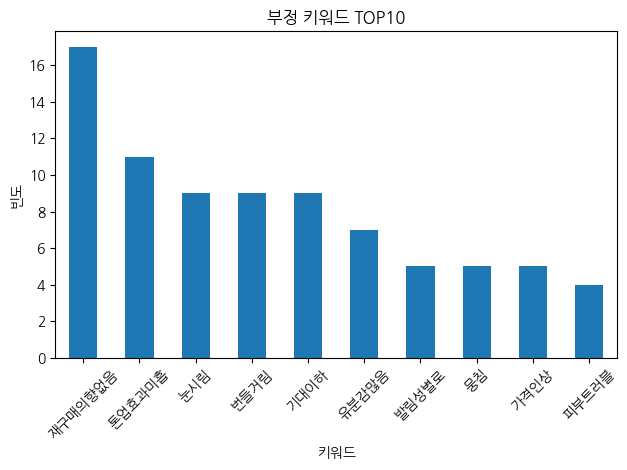

In [ ]:
import matplotlib.pyplot as plt

# 부정 키워드 상위 10개
top10 = negative_keyword_counts.head(10)

plt.figure()
top10.plot(kind='bar')

plt.title('부정 키워드 TOP10')
plt.xlabel('키워드')
plt.ylabel('빈도')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#  긍정율 열 생성된 DF 저장
df.to_csv('헤라_v7.csv', index=False)

### 2. 톤업 선크림(신제품) 긍정/부정 별 가장 많이 도출된 키워드 분석
- UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml | 50165
- NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml | 68573

### 분석 결과
- UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml | 50165
  * 긍/부정 리뷰의 키워드가 헤라 전제품의 리뷰 키워드와 전반적으로 비슷하다
- NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml | 68573
  * 리뷰 표본 자체가 35개로 적은 편에 속한다. 전반적으로 만족하는 편이고, 선물용에 대한 리뷰도 긍정에 속한다.
  * 부정리뷰는 1개 뿐이기에, 사용감 | 민감성 | 발림성 열의 내용을 기반으로 도출된 내용인 뻑뻑함, 유분기 많음, 자극적임 정도의 인사이트를 얻는 것으로 한다.

In [ ]:
df = pd.read_csv('헤라_v7.csv')
df.columns

Index(['제품명', '제품 ID', '용량', '판매가', '정가', '할인율', '평점', '총리뷰수', '작성자', '연령대',
       '성별', '피부타입', '피부고민', '별점', '사용감', '민감성', '발림성', '리뷰내용', '작성일자', '키워드',
       '감성분석', '긍정률'],
      dtype='object')

#### UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml | 50165

In [ ]:
import ast

df['키워드'] = df['키워드'].apply(ast.literal_eval)

# Filter for 'UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml'
pitch_toneup_df = df[df['제품 ID'] == 50165]

# 긍정 리뷰 키워드
positive_pitch_reviews = pitch_toneup_df[pitch_toneup_df['감성분석'] == '긍정']
exploded_positive_pitch_keywords = positive_pitch_reviews.explode('키워드')
positive_pitch_keyword_counts = exploded_positive_pitch_keywords['키워드'].value_counts()

print("Top 10 Positive Keywords for UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml:")
display(positive_pitch_keyword_counts.head(20))

Top 10 Positive Keywords for UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml:


,count
키워드,
톤업,3091
재구매의향,1946
발림성좋음,1778
촉촉함,1104
화사함,1093
만족도높음,1060
순함,594
재구매,571
만족,522


In [ ]:
keyword_map = {
'자연스러운톤업' : '톤업',
'눈물' : '눈시림'
}

In [ ]:
df['키워드'] = df['키워드'].apply(
    lambda keywords: [
      keyword_map.get(k.strip(), k.strip()) for k in keywords
    ] if isinstance(keywords, list) else keywords
)

In [ ]:
# 긍정
target_df = df[
    (df['제품명'] == 'UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml') &
    (df['감성분석'] == '긍정')
]
exploded_keywords = target_df.explode('키워드')
top10_keywords = exploded_keywords['키워드'].value_counts().head(10)
top10_df = top10_keywords.reset_index()
top10_df.columns = ['키워드', '빈도']
display(top10_df)

,키워드,빈도
0,톤업,3494
1,재구매의향,1946
2,발림성좋음,1778
3,촉촉함,1104
4,화사함,1093
5,만족도높음,1060
6,순함,594
7,재구매,571
8,만족,522
9,끈적임없음,490


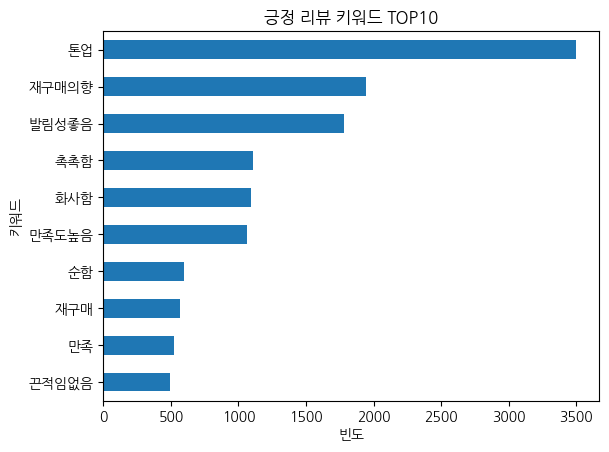

In [ ]:
import matplotlib.pyplot as plt

top10_keywords.sort_values().plot(kind='barh')
plt.title('긍정 리뷰 키워드 TOP10')
plt.xlabel('빈도')
plt.ylabel('키워드')
plt.show()

In [ ]:
# 부정
target_df = df[
    (df['제품명'] == 'UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml') &
    (df['감성분석'] == '부정')
]

exploded_keywords = target_df.explode('키워드')

top10_keywords = exploded_keywords['키워드'].value_counts().head(10)

top10_df = top10_keywords.reset_index()
top10_df.columns = ['키워드', '빈도']

display(top10_df)

,키워드,빈도
0,재구매의향없음,11
1,톤업효과미흡,10
2,눈시림,8
3,기대이하,7
4,번들거림,5
5,불만족,3
6,뭉침,3
7,구매이유없음,2
8,밀림,2
9,발림성별로,2


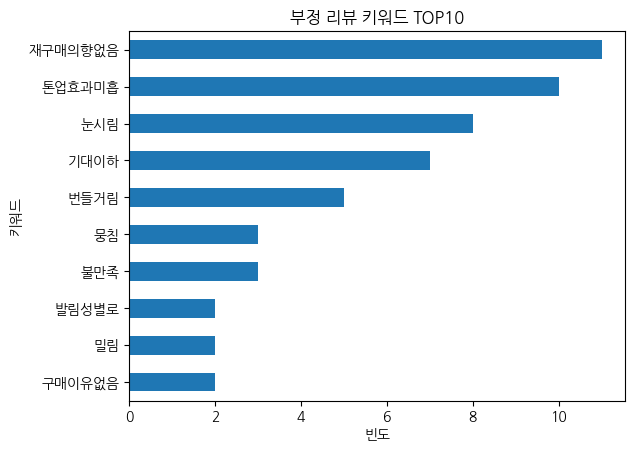

In [ ]:
import matplotlib.pyplot as plt

top10_keywords.sort_values().plot(kind='barh')
plt.title('부정 리뷰 키워드 TOP10')
plt.xlabel('빈도')
plt.ylabel('키워드')
plt.show()

#### NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml | 68573

In [ ]:
import pandas as pd
df = pd.read_csv('헤라_v7.csv')

In [ ]:
# 긍정
import ast

df['키워드'] = df['키워드'].apply(ast.literal_eval)

# Filter for 'NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml'
pitch_toneup_df = df[df['제품 ID'] == 68573]

# 긍정 리뷰 키워드
positive_pitch_reviews = pitch_toneup_df[pitch_toneup_df['감성분석'] == '긍정']
exploded_positive_pitch_keywords = positive_pitch_reviews.explode('키워드')
positive_pitch_keyword_counts = exploded_positive_pitch_keywords['키워드'].value_counts()

print("Top 10 Positive Keywords for NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml:")
display(positive_pitch_keyword_counts.head(10))

Top 10 Positive Keywords for NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml:


,count
키워드,
톤업,5
화사함,4
재구매의향,4
발림성좋음,4
만족,4
만족도높음,3
선물만족,2
피부톤개선,2
번들거림없음,2


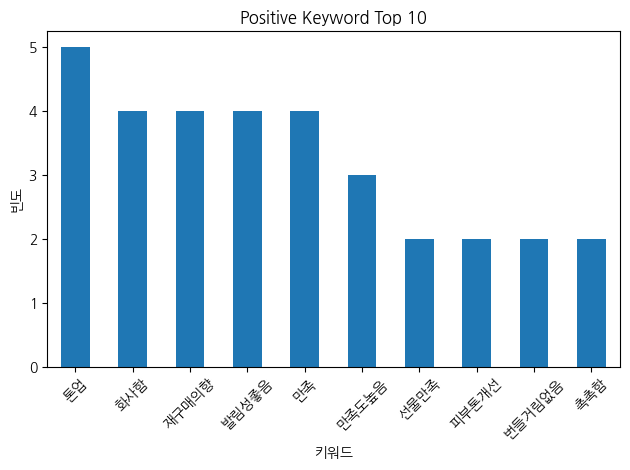

In [ ]:
import matplotlib.pyplot as plt

top10 = positive_pitch_keyword_counts.head(10)

plt.figure()
top10.plot(kind='bar')

plt.title('Positive Keyword Top 10')
plt.xlabel('키워드')
plt.ylabel('빈도')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
negative_df = df[
    (df['제품 ID'] == 68573) &
    (df['감성분석'] == '부정')
]

display(negative_df)

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,...,피부고민,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드,감성분석,긍정률
1491,NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml,68573,50ml,42300,47000,10%,4.6,35,luab***,40대,...,민감성,1,유분기 있어요,자극적이에요,뻑뻑해요,리뉴얼전 세통정도 썼었는데요 결론적으론 라벤더는 추천하지 않아요 건조하고 유분은 번...,2026.03.06,"['라벤더비추천', '건조함', '유분번들거림', '밀림현상']",부정,0.828571


### 3. 톤업 선크림(신제품) 연령대와 성별, 긍정/부정/중립 별 가장 많이 도출된 키워드 분석
- UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml | 50165
- NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml | 68573

### 분석 결과
- UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml | 50165
  * 부정 리뷰의 남성 리뷰는 빈도가 매우 적어(1회) 인사이트를 얻을 수 없을 거라 판단된다.
- NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml | 68573
  * 리뷰 자체가 적어 시각화 의미가 없다고 판단된다.

In [ ]:
import pandas as pd
df = pd.read_csv('헤라_v7.csv')
df.columns

Index(['제품명', '제품 ID', '용량', '판매가', '정가', '할인율', '평점', '총리뷰수', '작성자', '연령대',
       '성별', '피부타입', '피부고민', '별점', '사용감', '민감성', '발림성', '리뷰내용', '작성일자', '키워드',
       '감성분석', '긍정률'],
      dtype='object')

In [ ]:
df['연령대'].value_counts()

,count
연령대,
40대,7265
50대 이상,6590
30대,4766
20대,1315
10대,38


#### UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml | 50165

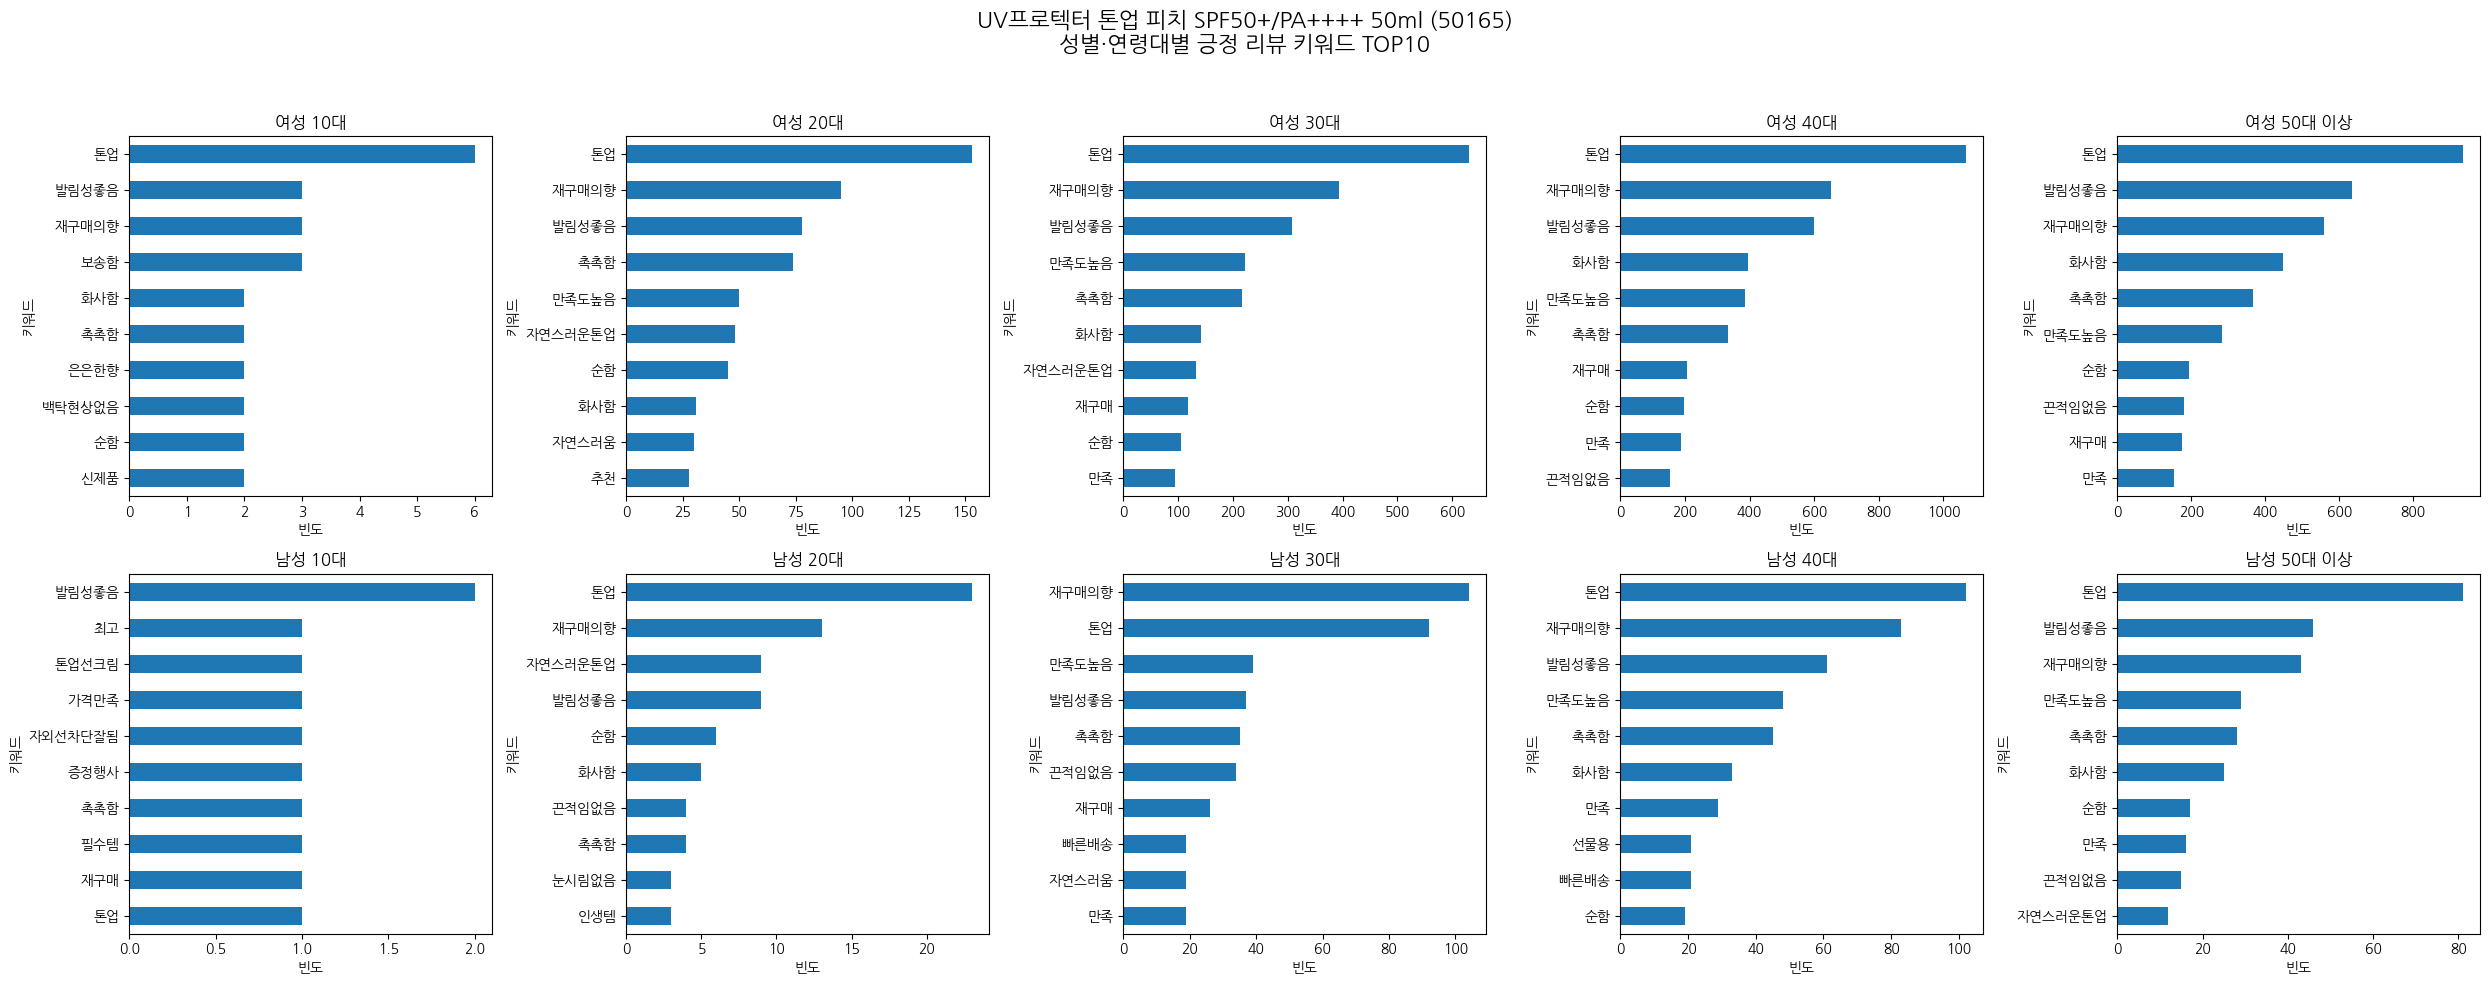

In [ ]:
# 긍정
import ast
import matplotlib.pyplot as plt

# 키워드가 문자열이면 리스트로 변환
df['키워드'] = df['키워드'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# 50165 + 긍정 리뷰만 필터링
target_df = df[
    (df['제품 ID'] == 50165) &
    (df['감성분석'] == '긍정')
].copy()

# 보고 싶은 순서 고정
gender_order = ['여성', '남성']
age_order = ['10대', '20대', '30대', '40대', '50대 이상']

# 2행 5열 서브플롯
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

plot_idx = 0

for gender in gender_order:
    for age in age_order:
        ax = axes[plot_idx]

        subset = target_df[
            (target_df['성별'] == gender) &
            (target_df['연령대'] == age)
        ]

        if subset.empty:
            ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', fontsize=12)
            ax.set_title(f'{gender} {age}')
            ax.axis('off')
        else:
            exploded = subset.explode('키워드')
            keyword_counts = exploded['키워드'].value_counts().head(10).sort_values()

            keyword_counts.plot(kind='barh', ax=ax)
            ax.set_title(f'{gender} {age}')
            ax.set_xlabel('빈도')
            ax.set_ylabel('키워드')

        plot_idx += 1

plt.suptitle('UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml (50165)\n성별·연령대별 긍정 리뷰 키워드 TOP10', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

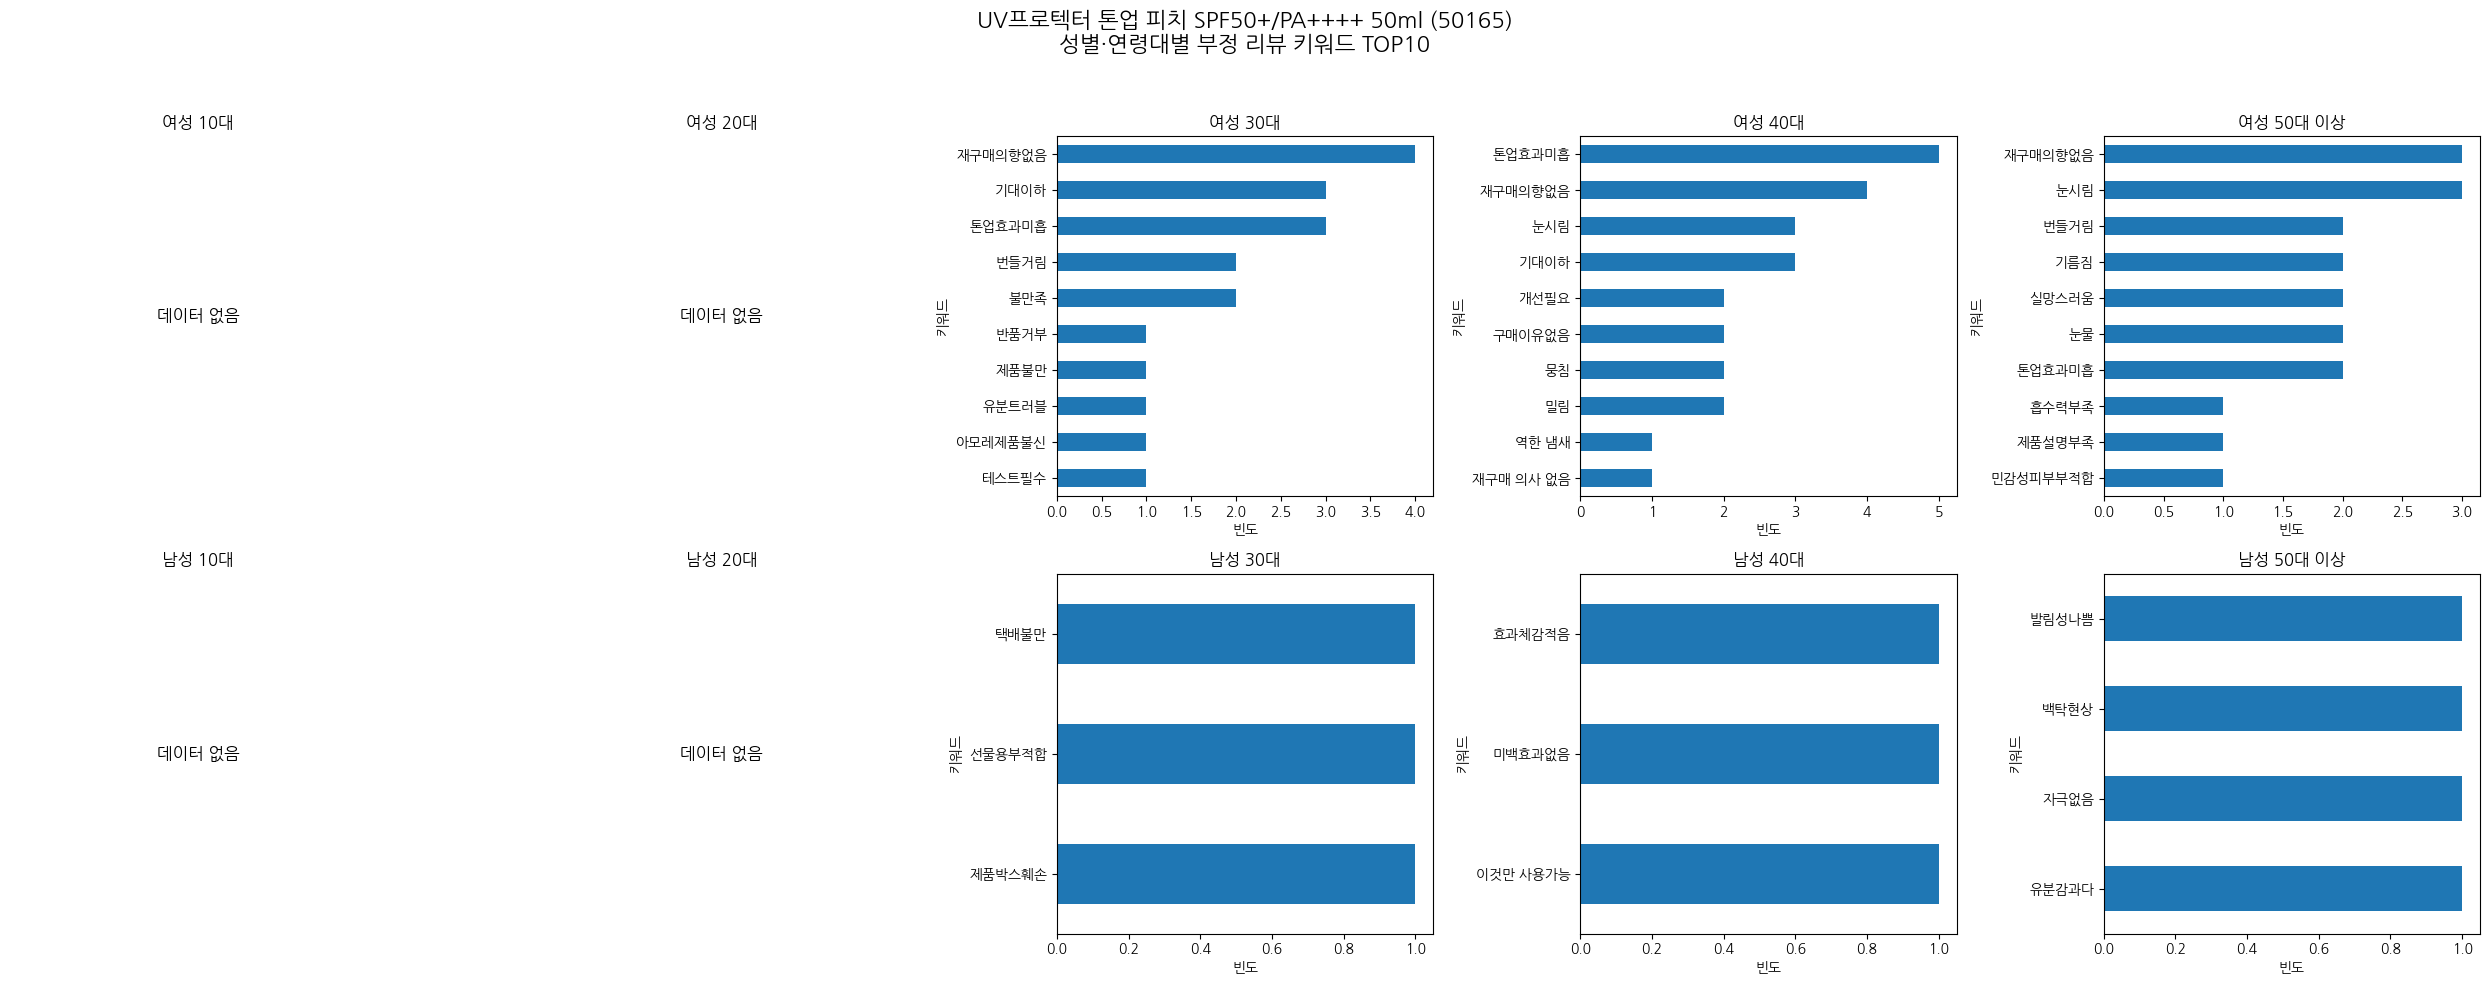

In [ ]:
# 부정
import ast
import matplotlib.pyplot as plt

# 50165 + 부정 리뷰만 필터링
target_df = df[
    (df['제품 ID'] == 50165) &
    (df['감성분석'] == '부정')
].copy()

# 보고 싶은 순서 고정
gender_order = ['여성', '남성']
age_order = ['10대', '20대', '30대', '40대', '50대 이상']

# 2행 5열 서브플롯
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

plot_idx = 0

for gender in gender_order:
    for age in age_order:
        ax = axes[plot_idx]

        subset = target_df[
            (target_df['성별'] == gender) &
            (target_df['연령대'] == age)
        ]

        if subset.empty:
            ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', fontsize=12)
            ax.set_title(f'{gender} {age}')
            ax.axis('off')
        else:
            exploded = subset.explode('키워드')
            keyword_counts = exploded['키워드'].value_counts().head(10).sort_values()

            keyword_counts.plot(kind='barh', ax=ax)
            ax.set_title(f'{gender} {age}')
            ax.set_xlabel('빈도')
            ax.set_ylabel('키워드')

        plot_idx += 1

plt.suptitle('UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml (50165)\n성별·연령대별 부정 리뷰 키워드 TOP10', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml | 68573

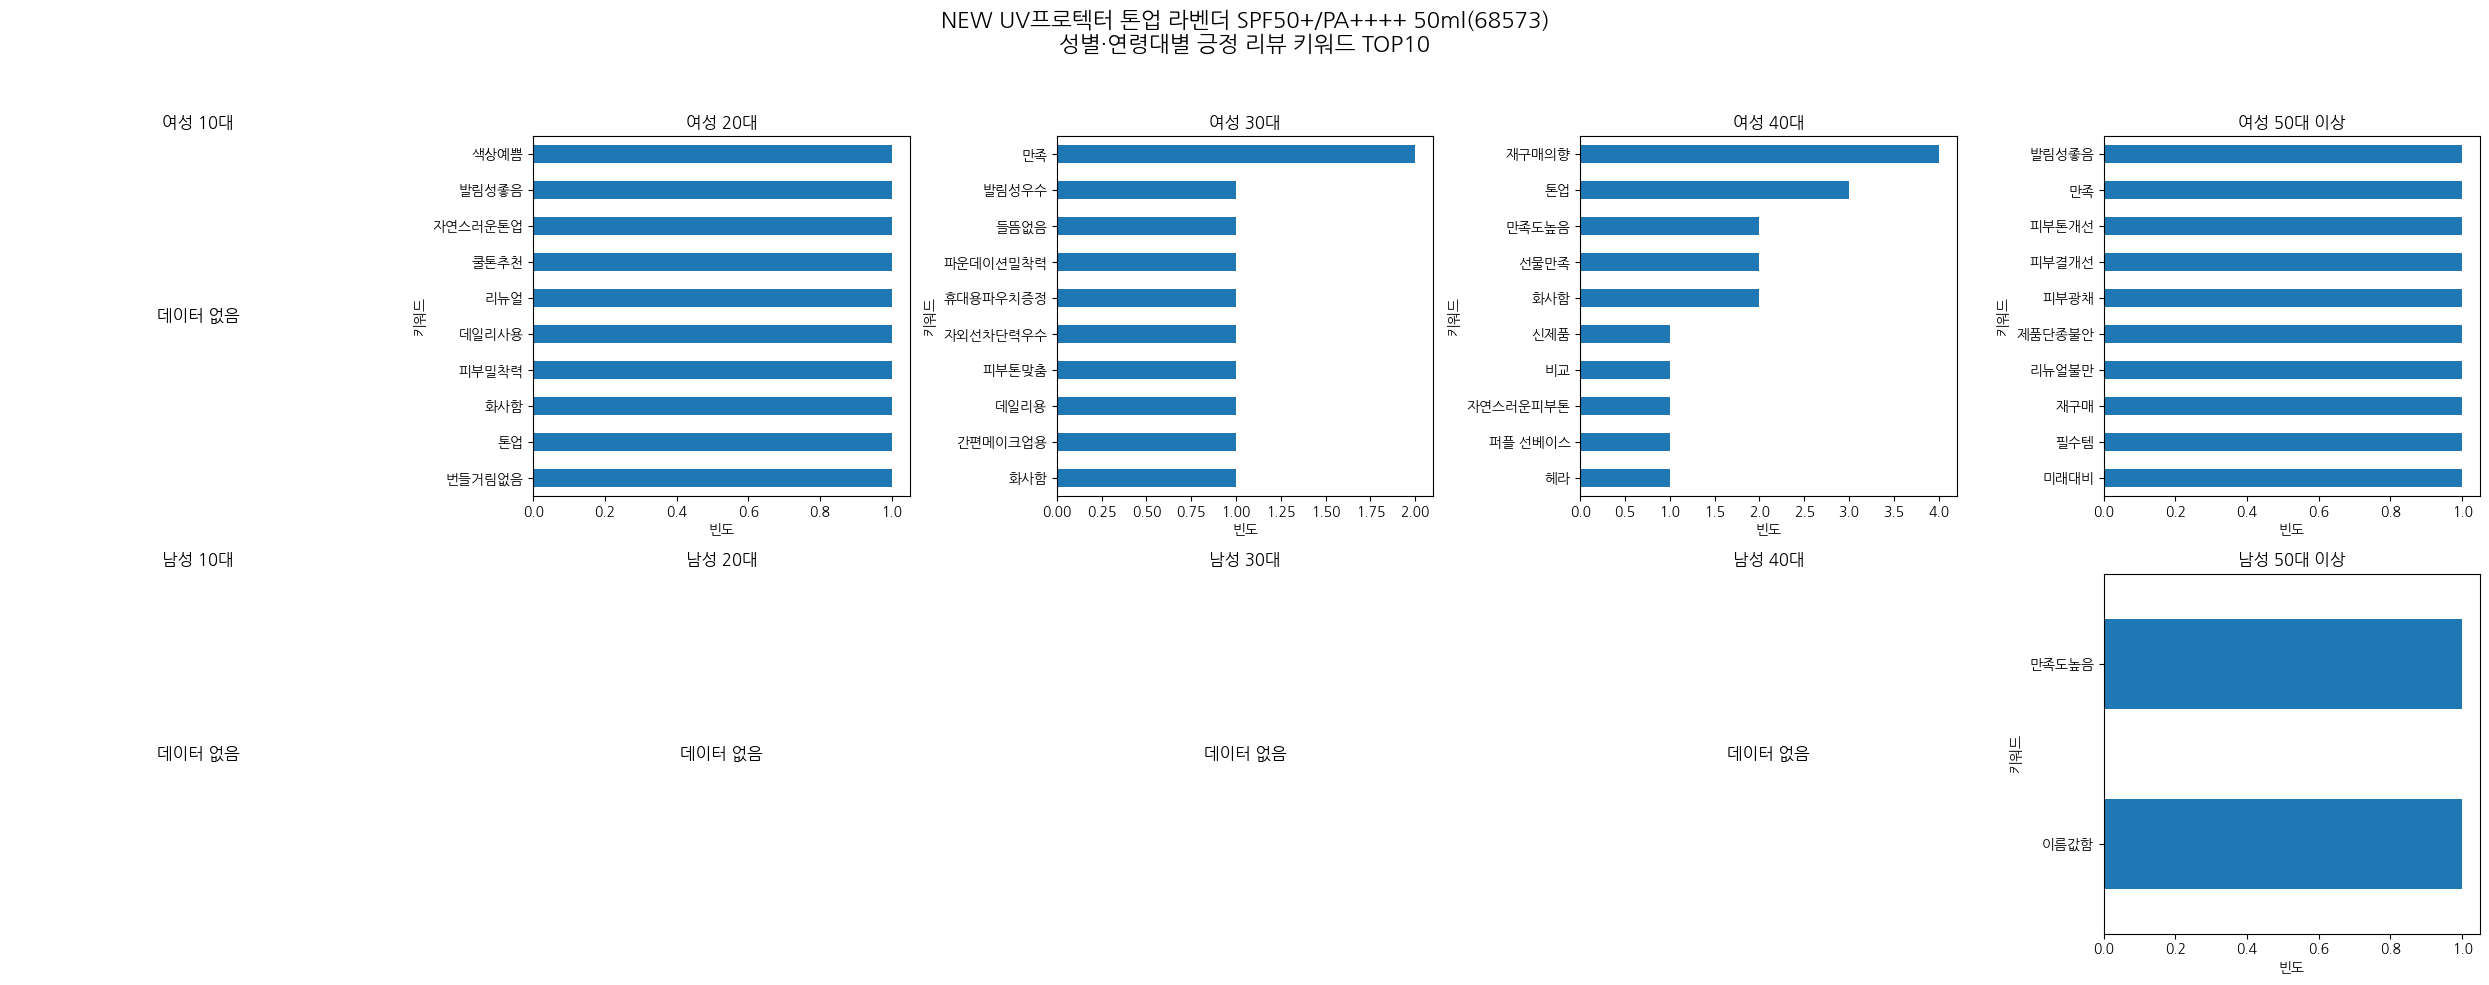

In [ ]:
# 긍정
import ast
import matplotlib.pyplot as plt

# 68573 + 긍정 리뷰만 필터링
target_df = df[
    (df['제품 ID'] == 68573) &
    (df['감성분석'] == '긍정')
].copy()

# 보고 싶은 순서 고정
gender_order = ['여성', '남성']
age_order = ['10대', '20대', '30대', '40대', '50대 이상']

# 2행 5열 서브플롯
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

plot_idx = 0

for gender in gender_order:
    for age in age_order:
        ax = axes[plot_idx]

        subset = target_df[
            (target_df['성별'] == gender) &
            (target_df['연령대'] == age)
        ]

        if subset.empty:
            ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', fontsize=12)
            ax.set_title(f'{gender} {age}')
            ax.axis('off')
        else:
            exploded = subset.explode('키워드')
            keyword_counts = exploded['키워드'].value_counts().head(10).sort_values()

            keyword_counts.plot(kind='barh', ax=ax)
            ax.set_title(f'{gender} {age}')
            ax.set_xlabel('빈도')
            ax.set_ylabel('키워드')

        plot_idx += 1

plt.suptitle('NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml(68573)\n성별·연령대별 긍정 리뷰 키워드 TOP10', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

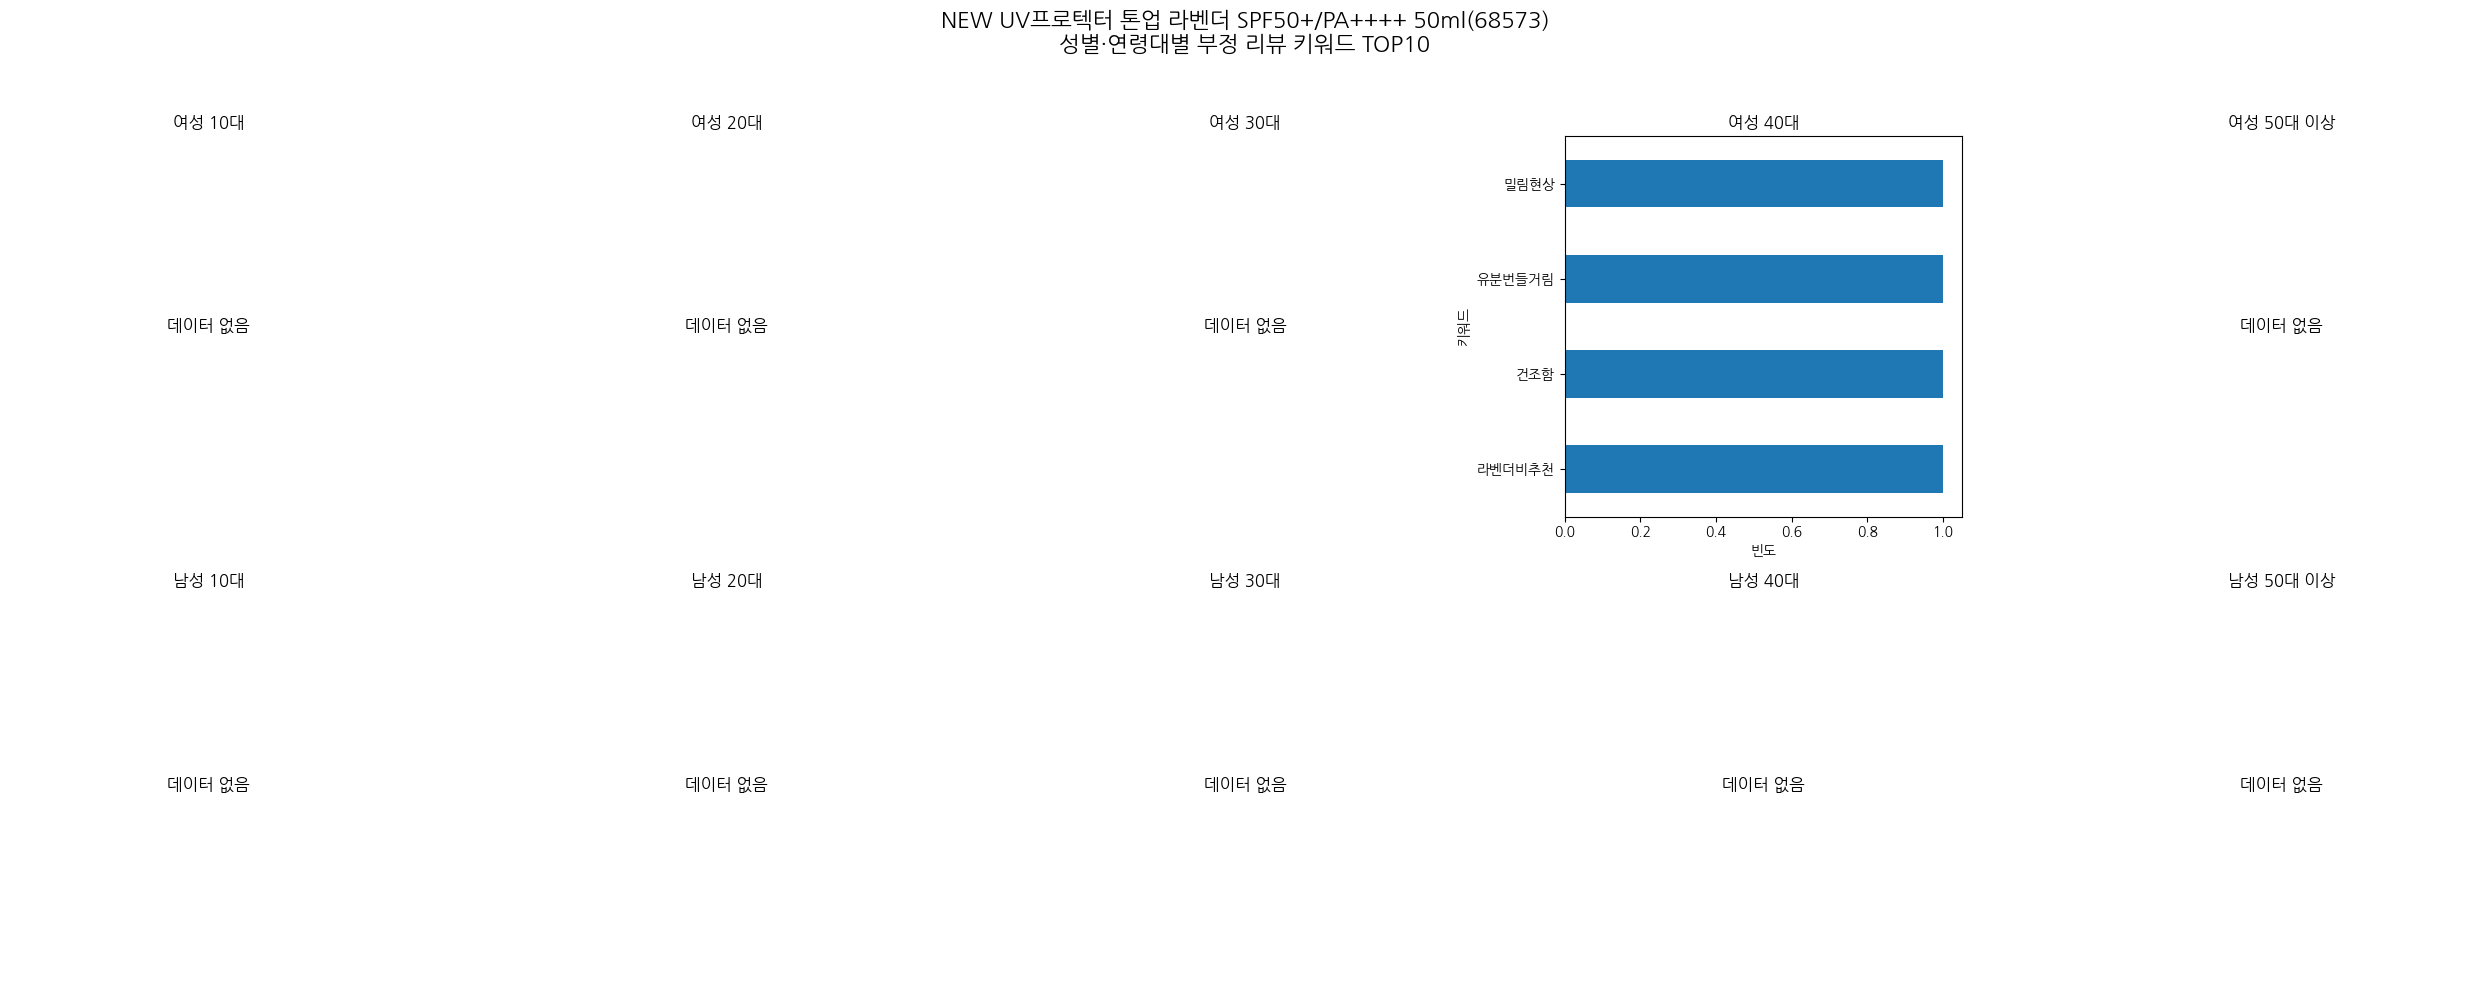

In [ ]:
# 부정
import ast
import matplotlib.pyplot as plt

# 68573 + 부정 리뷰만 필터링
target_df = df[
    (df['제품 ID'] == 68573) &
    (df['감성분석'] == '부정')
].copy()

# 보고 싶은 순서 고정
gender_order = ['여성', '남성']
age_order = ['10대', '20대', '30대', '40대', '50대 이상']

# 2행 5열 서브플롯
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

plot_idx = 0

for gender in gender_order:
    for age in age_order:
        ax = axes[plot_idx]

        subset = target_df[
            (target_df['성별'] == gender) &
            (target_df['연령대'] == age)
        ]

        if subset.empty:
            ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', fontsize=12)
            ax.set_title(f'{gender} {age}')
            ax.axis('off')
        else:
            exploded = subset.explode('키워드')
            keyword_counts = exploded['키워드'].value_counts().head(10).sort_values()

            keyword_counts.plot(kind='barh', ax=ax)
            ax.set_title(f'{gender} {age}')
            ax.set_xlabel('빈도')
            ax.set_ylabel('키워드')

        plot_idx += 1

plt.suptitle('NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml(68573)\n성별·연령대별 부정 리뷰 키워드 TOP10', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## (2차분석) 부정률 계산 및 제품 별 세부 분석
- 1. 긍정률을 구하는 가중치와 동일하게 부정률도 감성분석 열의 긍/부정/중립에 각각 0.0/1.0/0.5를 부여하여 계산하기로 한다.
- 2. 제품 별로 가장 긍정률이 높은 타겟층(연령대/성별)을 구한다. 그리고 우리의 타겟 30대 남성은 어느정도의 순위에 있는지 파악한다.

### 1. 부정률 구하기

In [ ]:
import pandas as pd
df = pd.read_csv('헤라_v7.csv')
df

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,...,피부고민,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드,감성분석,긍정률
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,gala*****,20대,...,모공,5,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14,"['선스틱', '덧바르기좋음', '휴대성좋음', '투명발림', '메이크업밀림없음',...",긍정,0.83391
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,wltn***,20대,...,모공,3,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,"['사무실덧바름쏘쏘', '피부자극있음', '유분감있음', '자연스러운광', '아웃도...",중립,0.83391
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,tjdu*****,20대,...,건조함,5,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,"['야외활동용', '자외선차단필수', '덧바르기좋음', '민감성피부용', '휴대성좋...",긍정,0.83391
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,마티니,30대,...,민감성,3,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,"['기름짐', '사용량많음', '미끌거림', '끈적임']",부정,0.83391
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,yjba****,50대 이상,...,주름,5,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,"['끈적임적음', '덧바르기편함', '색묻어남없음', '휴대성좋음', '양적음']",중립,0.83391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19969,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,...,주름,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.12.01,['만족'],긍정,0.92881
19970,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,...,주름,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.11.10,['만족도높음'],긍정,0.92881
19971,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,...,주름,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.09.28,"['만족도높음', '호감', '추천']",긍정,0.92881
19972,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,very***,20대,...,건조함,5,적당해요,적당해요,잘 발려요,아모레퍼시픽몰에서 판매하는 UV 프로텍터를 저렴한 가격과 알찬구성으로 구입할 수 있...,2019.06.11,"['저렴한가격', '알찬구성', '향이좋음', '자극적이지않음', '대량구매가능']",긍정,0.92881


In [ ]:
df = df[df['감성분석'].isin(['긍정', '중립', '부정'])]
df['감성분석'].value_counts()

sentiment_scores = {
    '긍정': 0,
    '중립': 0.5,
    '부정': 1
}

df['감성점수'] = df['감성분석'].map(sentiment_scores)

# 제품별 긍정률 계산 (평균 감성점수)
df['부정률'] = df.groupby('제품 ID')['감성점수'].transform('mean')

# '감성점수' 열은 더 이상 필요 없으므로 삭제합니다.
df = df.drop(columns=['감성점수'])

df.head()

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,...,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드,감성분석,긍정률,부정률
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,gala*****,20대,...,5,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14,"['선스틱', '덧바르기좋음', '휴대성좋음', '투명발림', '메이크업밀림없음',...",긍정,0.83391,0.16609
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,wltn***,20대,...,3,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,"['사무실덧바름쏘쏘', '피부자극있음', '유분감있음', '자연스러운광', '아웃도...",중립,0.83391,0.16609
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,tjdu*****,20대,...,5,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,"['야외활동용', '자외선차단필수', '덧바르기좋음', '민감성피부용', '휴대성좋...",긍정,0.83391,0.16609
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,마티니,30대,...,3,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,"['기름짐', '사용량많음', '미끌거림', '끈적임']",부정,0.83391,0.16609
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,yjba****,50대 이상,...,5,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,"['끈적임적음', '덧바르기편함', '색묻어남없음', '휴대성좋음', '양적음']",중립,0.83391,0.16609


In [ ]:
df.groupby('제품명')['부정률'].mean()

,부정률
제품명,
NEW UV프로텍터 CC SPF50+/PA++++ 50ml,0.155172
NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml,0.171429
UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,0.071190
UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,0.166090
UV프로텍터 익스트림포스 레포츠 SPF50+/PA++++ 70ml,0.061688
UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,0.068650
UV프로텍터 프레쉬 SPF50+/PA++++ 50ml,0.058573


In [ ]:
df.to_csv('헤라_v8.csv', index =False)

### 제품 별 인기 소비층 구하기
- 리뷰수 즉 표본이 적은 층에서 긍정률이 높게 나오는 현상이 발견되었다.
- 성별 연령대별 리뷰 수를 기준으로 인기 척도를 설정하도록 한다.

In [ ]:
import pandas as pd
df = pd.read_csv('헤라_v8.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19974 entries, 0 to 19973
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제품명     19974 non-null  object 
 1   제품 ID   19974 non-null  int64  
 2   용량      19974 non-null  object 
 3   판매가     19974 non-null  int64  
 4   정가      19974 non-null  int64  
 5   할인율     19974 non-null  object 
 6   평점      19974 non-null  float64
 7   총리뷰수    19974 non-null  int64  
 8   작성자     19974 non-null  object 
 9   연령대     19974 non-null  object 
 10  성별      19974 non-null  object 
 11  피부타입    19974 non-null  object 
 12  피부고민    19974 non-null  object 
 13  별점      19974 non-null  int64  
 14  사용감     19974 non-null  object 
 15  민감성     19974 non-null  object 
 16  발림성     19974 non-null  object 
 17  리뷰내용    19974 non-null  object 
 18  작성일자    19974 non-null  object 
 19  키워드     19974 non-null  object 
 20  감성분석    19974 non-null  object 
 21  긍정률     19974 non-null  float64
 22

In [ ]:
# 제품 별긍정률이 가장 높은 층(성별/연령대)
import pandas as pd

# 감성분석 점수 맵핑
positive_map = {
    '긍정': 1.0,
    '중립': 0.5,
    '부정': 0.0
}

# 긍정 점수 열 만들기
df['긍정점수'] = df['감성분석'].map(positive_map)

# 제품명-연령대-성별별 긍정률 계산
target_df = (
    df.groupby(['제품명', '연령대', '성별'], as_index=False)
      .agg(
          긍정률=('긍정점수', 'mean'),
          리뷰수=('감성분석', 'count')
      )
)

# 제품명별로 긍정률이 가장 높은 조합만 추출
best_target_df = (
    target_df.sort_values(['제품명', '긍정률', '리뷰수'], ascending=[True, False, False])
             .drop_duplicates(subset='제품명')
             .reset_index(drop=True)
)

best_target_df

,제품명,연령대,성별,긍정률,리뷰수
0,NEW UV프로텍터 CC SPF50+/PA++++ 50ml,30대,여성,1.000000,6
1,NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml,20대,여성,1.000000,2
2,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,10대,남성,1.000000,5
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,10대,여성,1.000000,1
4,UV프로텍터 익스트림포스 레포츠 SPF50+/PA++++ 70ml,40대,남성,0.985714,35
5,UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,10대,남성,1.000000,4
6,UV프로텍터 프레쉬 SPF50+/PA++++ 50ml,40대,남성,0.966102,177


In [ ]:
pivot_df = pd.pivot_table(
    df,
    index='제품명',
    columns=['성별', '연령대'],
    values='감성분석',  # 아무 컬럼이나 가능
    aggfunc='count',
    fill_value=0
)

pivot_df

성별                                    남성                       여성             \
연령대                                  10대 20대  30대  40대 50대 이상 10대  20대   30대   
제품명                                                                            
NEW UV프로텍터 CC SPF50+/PA++++ 50ml       0   0    1    0      1   0    1     6   
NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml   0   1    3    0      2   0    2     7   
UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml        5  47  222  232    159  10  414  1214   
UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g      0   5   36   38     51   1   50   307   
UV프로텍터 익스트림포스 레포츠 SPF50+/PA++++ 70ml   0   2   19   35     33   1   51   165   
UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml        4  60  340  386    269  15  564  2027   
UV프로텍터 프레쉬 SPF50+/PA++++ 50ml          0  14   54  177     39   2  104   365   

성별                                                 
연령대                                    40대 50대 이상  
제품명                                                
NEW UV프로텍터 CC SPF50+/PA++++ 50ml        13      7  
NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml    15      5  
UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml       1596   1481  
UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g      538    419  
UV프로텍터 익스트림포스 레포츠 SPF50+/PA++++ 70ml   219    245  
UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml       3427   3345  
UV프로텍터 프레쉬 SPF50+/PA++++ 50ml          589    534

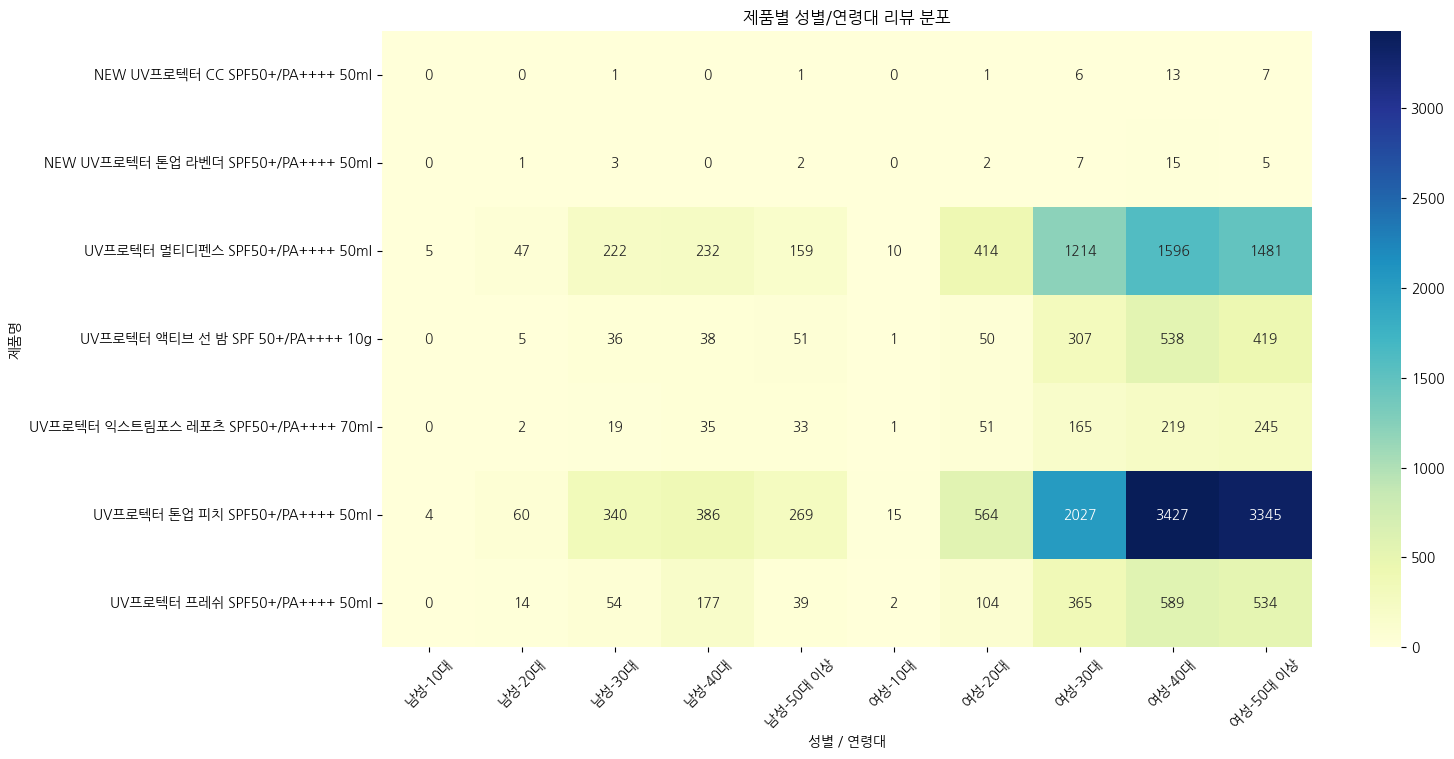

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

sns.heatmap(
    pivot_df,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('제품별 성별/연령대 리뷰 분포')
plt.xlabel('성별 / 연령대')
plt.ylabel('제품명')

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

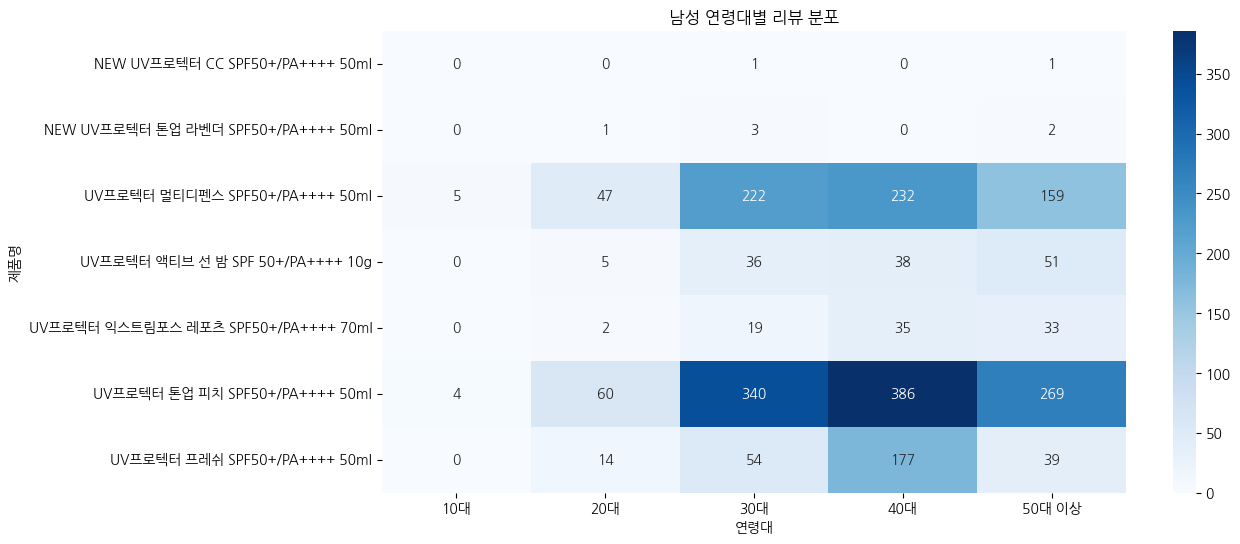

In [ ]:
male_df = pivot_df['남성']

plt.figure(figsize=(12, 6))

sns.heatmap(
    male_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('남성 연령대별 리뷰 분포')
plt.show()

##(3차분석) 긍부정률 x 총 리뷰 수

In [ ]:
import pandas as pd
df = pd.read_csv('헤라_v8.csv')
df

,제품명,제품 ID,용량,판매가,정가,할인율,평점,총리뷰수,작성자,연령대,...,별점,사용감,민감성,발림성,리뷰내용,작성일자,키워드,감성분석,긍정률,부정률
0,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,gala*****,20대,...,5,보송해요,순해요,잘 발려요,야외활동할 때 쓰기 좋은 헤라 액티브 선 밤 w 햇살이 뜨거워지는 시기에 꼭 필요한...,2025.05.14,"['선스틱', '덧바르기좋음', '휴대성좋음', '투명발림', '메이크업밀림없음',...",긍정,0.83391,0.16609
1,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,wltn***,20대,...,3,유분기 있어요,적당해요,적당해요,기대: 오후 사무실에서 선크림 덧바를 시 사용해야지~! or 평소에 나가서 놀다가 ...,2024.12.12,"['사무실덧바름쏘쏘', '피부자극있음', '유분감있음', '자연스러운광', '아웃도...",중립,0.83391,0.16609
2,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,tjdu*****,20대,...,5,적당해요,순해요,잘 발려요,야외 활동 시 사용하기 좋습니다. 햇살이 강해지는 계절에는 자외선 차단제가 필수인데...,2025.06.02,"['야외활동용', '자외선차단필수', '덧바르기좋음', '민감성피부용', '휴대성좋...",긍정,0.83391,0.16609
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,마티니,30대,...,3,유분기 있어요,적당해요,잘 발려요,"사이즈 자체는 휴대 목적이라 딱 좋은데, 제형이 너무 기름져서 그런지 줄어드는 속도...",2024.06.26,"['기름짐', '사용량많음', '미끌거림', '끈적임']",부정,0.83391,0.16609
4,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,57792,10g,34200,38000,10%,4.8,1446,yjba****,50대 이상,...,5,유분기 있어요,적당해요,잘 발려요,사실 유분기가 있어서 자외선 차단이 잘 되나 싶고 색도 안보이고 해서 제대로 잘 발...,2024.08.11,"['끈적임적음', '덧바르기편함', '색묻어남없음', '휴대성좋음', '양적음']",중립,0.83391,0.16609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19969,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,...,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.12.01,['만족'],긍정,0.92881,0.07119
19970,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,...,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.11.10,['만족도높음'],긍정,0.92881,0.07119
19971,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,dkdl****,50대 이상,...,5,보송해요,순해요,잘 발려요,좋아요 좋아요 좋아요 좋아요 좋아요 좋아요,2019.09.28,"['만족도높음', '호감', '추천']",긍정,0.92881,0.07119
19972,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,18312,50ml,42300,47000,10%,4.8,5386,very***,20대,...,5,적당해요,적당해요,잘 발려요,아모레퍼시픽몰에서 판매하는 UV 프로텍터를 저렴한 가격과 알찬구성으로 구입할 수 있...,2019.06.11,"['저렴한가격', '알찬구성', '향이좋음', '자극적이지않음', '대량구매가능']",긍정,0.92881,0.07119


In [ ]:
import pandas as pd
import numpy as np
# Install Korean font
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
# Configure Matplotlib to use NanumGothic
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking minus sign

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 19 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,214 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tt

In [ ]:
pip install adjustText

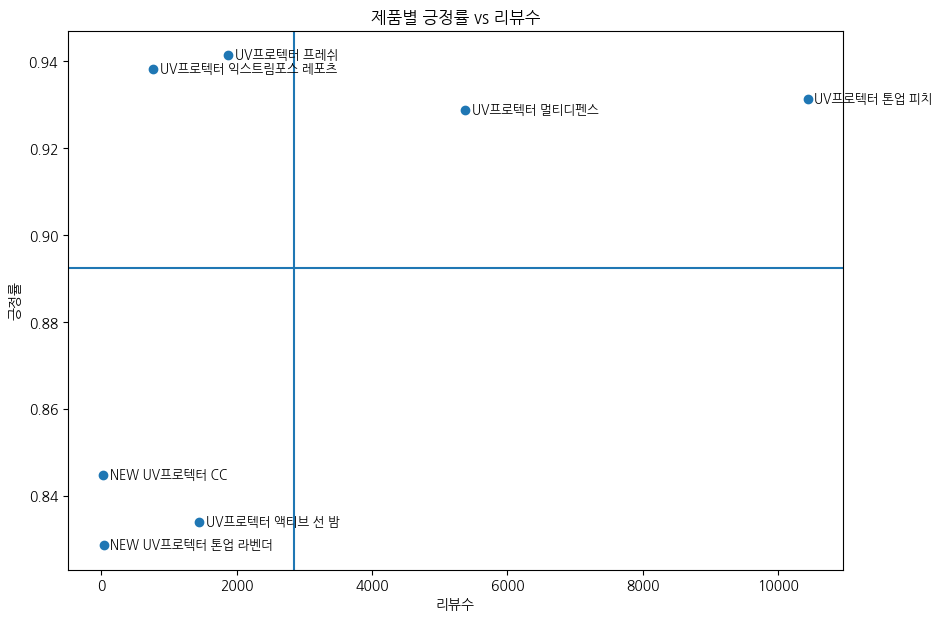

In [ ]:
import matplotlib.pyplot as plt

# 제품명 정리 (SPF 이후 제거)
product_summary['제품명_짧게'] = product_summary['제품명'].str.split('SPF').str[0]

plt.figure(figsize=(10,7))
plt.scatter(product_summary['리뷰수'], product_summary['긍정률'])

# 라벨 (점 바로 옆)
for i in range(len(product_summary)):
    plt.text(
        product_summary['리뷰수'][i] + 100,   # x축 살짝 이동
        product_summary['긍정률'][i],         # y는 그대로
        product_summary['제품명_짧게'][i],
        fontsize=9,
        verticalalignment='center'
    )

# 기준선
plt.axvline(review_mean)
plt.axhline(pos_mean)

plt.xlabel('리뷰수')
plt.ylabel('긍정률')
plt.title('제품별 긍정률 vs 리뷰수')

plt.show()

In [ ]:
result = (
    df.groupby('제품명')
    .agg(
        긍정률=('긍정률', 'mean'),
        부정률=('부정률', 'mean')
    )
    .reset_index()
    .sort_values('긍정률', ascending=False)
)

result['긍정률'] = result['긍정률'].round(3)
result['부정률'] = result['부정률'].round(3)

result

,제품명,긍정률,부정률
6,UV프로텍터 프레쉬 SPF50+/PA++++ 50ml,0.941,0.059
4,UV프로텍터 익스트림포스 레포츠 SPF50+/PA++++ 70ml,0.938,0.062
5,UV프로텍터 톤업 피치 SPF50+/PA++++ 50ml,0.931,0.069
2,UV프로텍터 멀티디펜스 SPF50+/PA++++ 50ml,0.929,0.071
0,NEW UV프로텍터 CC SPF50+/PA++++ 50ml,0.845,0.155
3,UV프로텍터 액티브 선 밤 SPF 50+/PA++++ 10g,0.834,0.166
1,NEW UV프로텍터 톤업 라벤더 SPF50+/PA++++ 50ml,0.829,0.171
